  CNN NOTEBOOK — Horizon J+1
  Window  : 48 pas = 4h d'historique
  Horizon : 288 pas = 1 jour(s) dans le futur
  PyTorch : 2.10.0+cpu

Dataset : 52116 pas × 325 capteurs
Période : 2017-01-01 00:00:00  →  2017-06-30 23:55:00
Vitesse : 0.0 – 85.1 km/h
Split   : 41692 train | 10424 test (80/20 chronologique)
Tableau normalisé : 68 MB ✓

Ajustement IncrementalPCA(50) sur l'ensemble train ...
Variance expliquée : 86.8% avec 50 composantes
Tableau PCA : 10 MB (vs 68 MB avant)
PCA terminé ✓


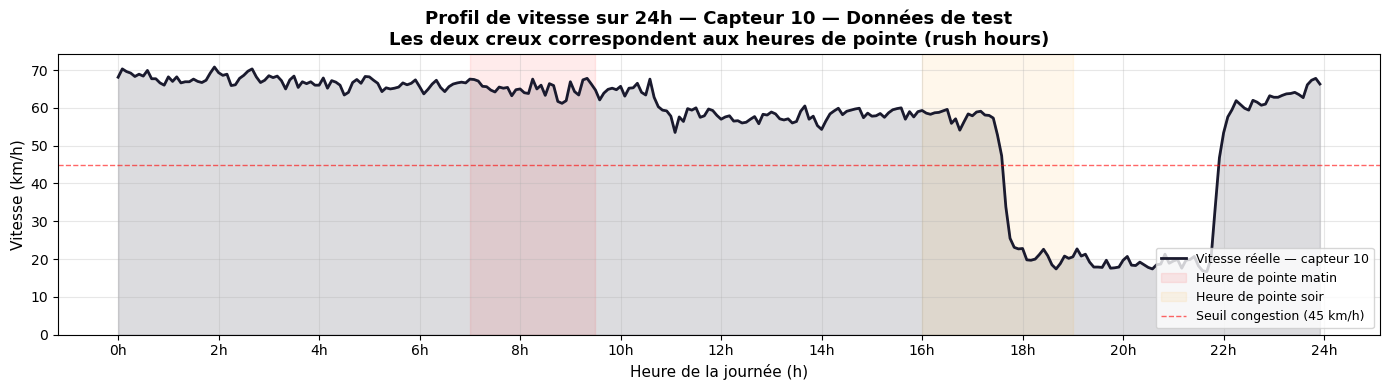


[Graphe 1] Profil 24h — Ce graphe montre la variabilité du trafic
   → Les creux = congestion. L'objectif : prédire ces creux 24h avant.

Fenêtres train : 41,424
Fenêtres test  : 10,357

Naïf     | MAE=3.055  RMSE=6.496  MAPE=6.6%  R²=0.487
HA       | MAE=2.466  RMSE=4.479  MAPE=5.4%  R²=0.756

Ajustement ARIMA(2,1,2) sur capteur 10 ...
ARIMA glissant (rolling) — patience ...
ARIMA multi  | MAE = 4.883 km/h
ARIMA rolling| MAE = 1.320 km/h


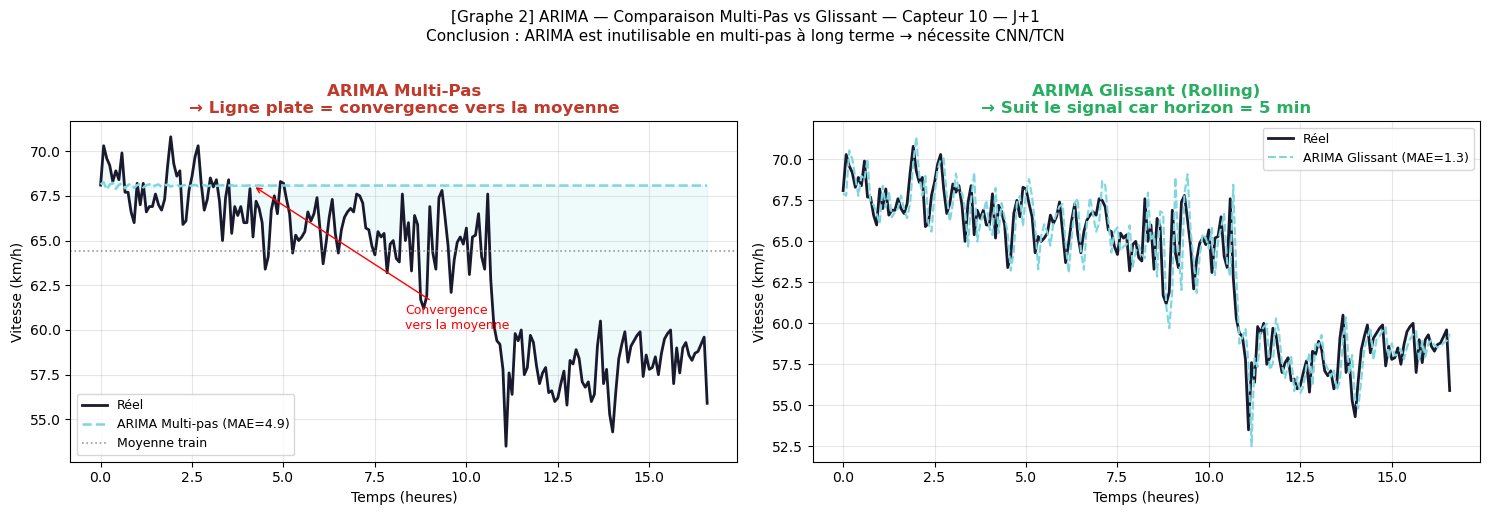

[Graphe 2] ARIMA Multi-pas vs Glissant sauvegardé ✓

Filtre de Kalman — capteur 10 ...
Kalman   | MAE=8.213  RMSE=15.443 km/h (capteur 10)

SVR — capteur 10 | fenêtre=24 | train=5000 ...
SVR      | MAE=6.656  RMSE=14.456 km/h (capteur 10)

CNN params : 43,154

───────────────────────────────────────────────────────
  Entraînement : CNN (dilaté)  (30 epochs)
───────────────────────────────────────────────────────
 Epoch     Train MSE     Val MSE          LR
     1      0.919376    0.949578    3.00e-04
     2      0.835072    0.938789    3.00e-04
     3      0.793968    0.947481    3.00e-04
     4      0.763559    0.953295    3.00e-04
     5      0.739563    0.965116    3.00e-04
     6      0.719703    0.989872    3.00e-04
     7      0.703360    1.010604    1.50e-04 ← LR↓
     8      0.686652    1.017598    1.50e-04
     9      0.679075    1.020895    1.50e-04
    10      0.673644    1.020004    1.50e-04
    11      0.667229    1.030448    1.50e-04
    12      0.661994    1.039313    7.

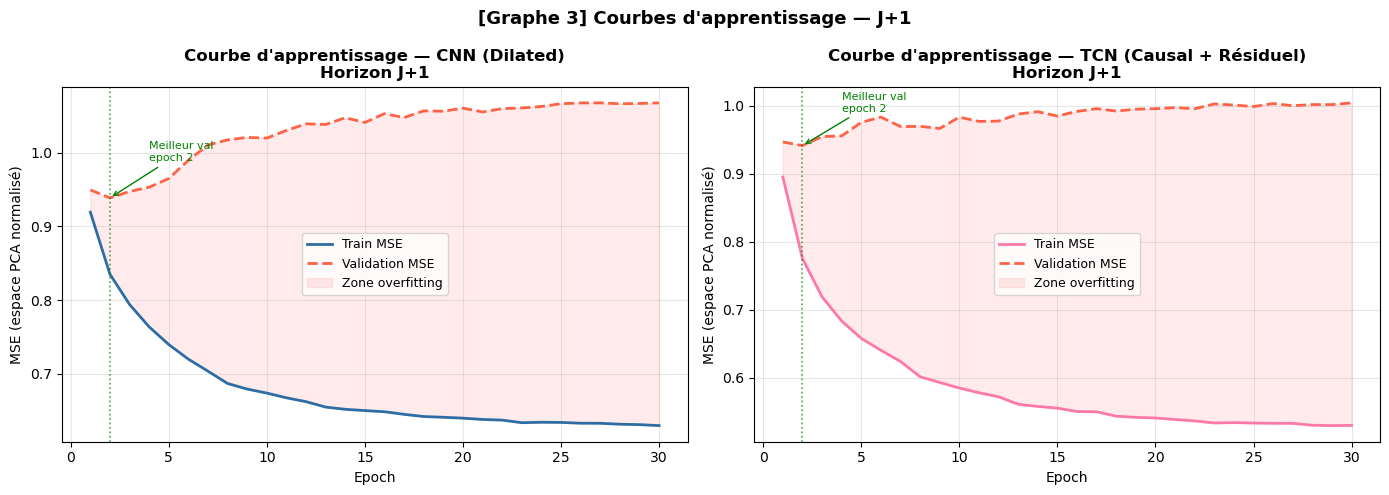

[Graphe 3] Courbes d'apprentissage sauvegardé ✓


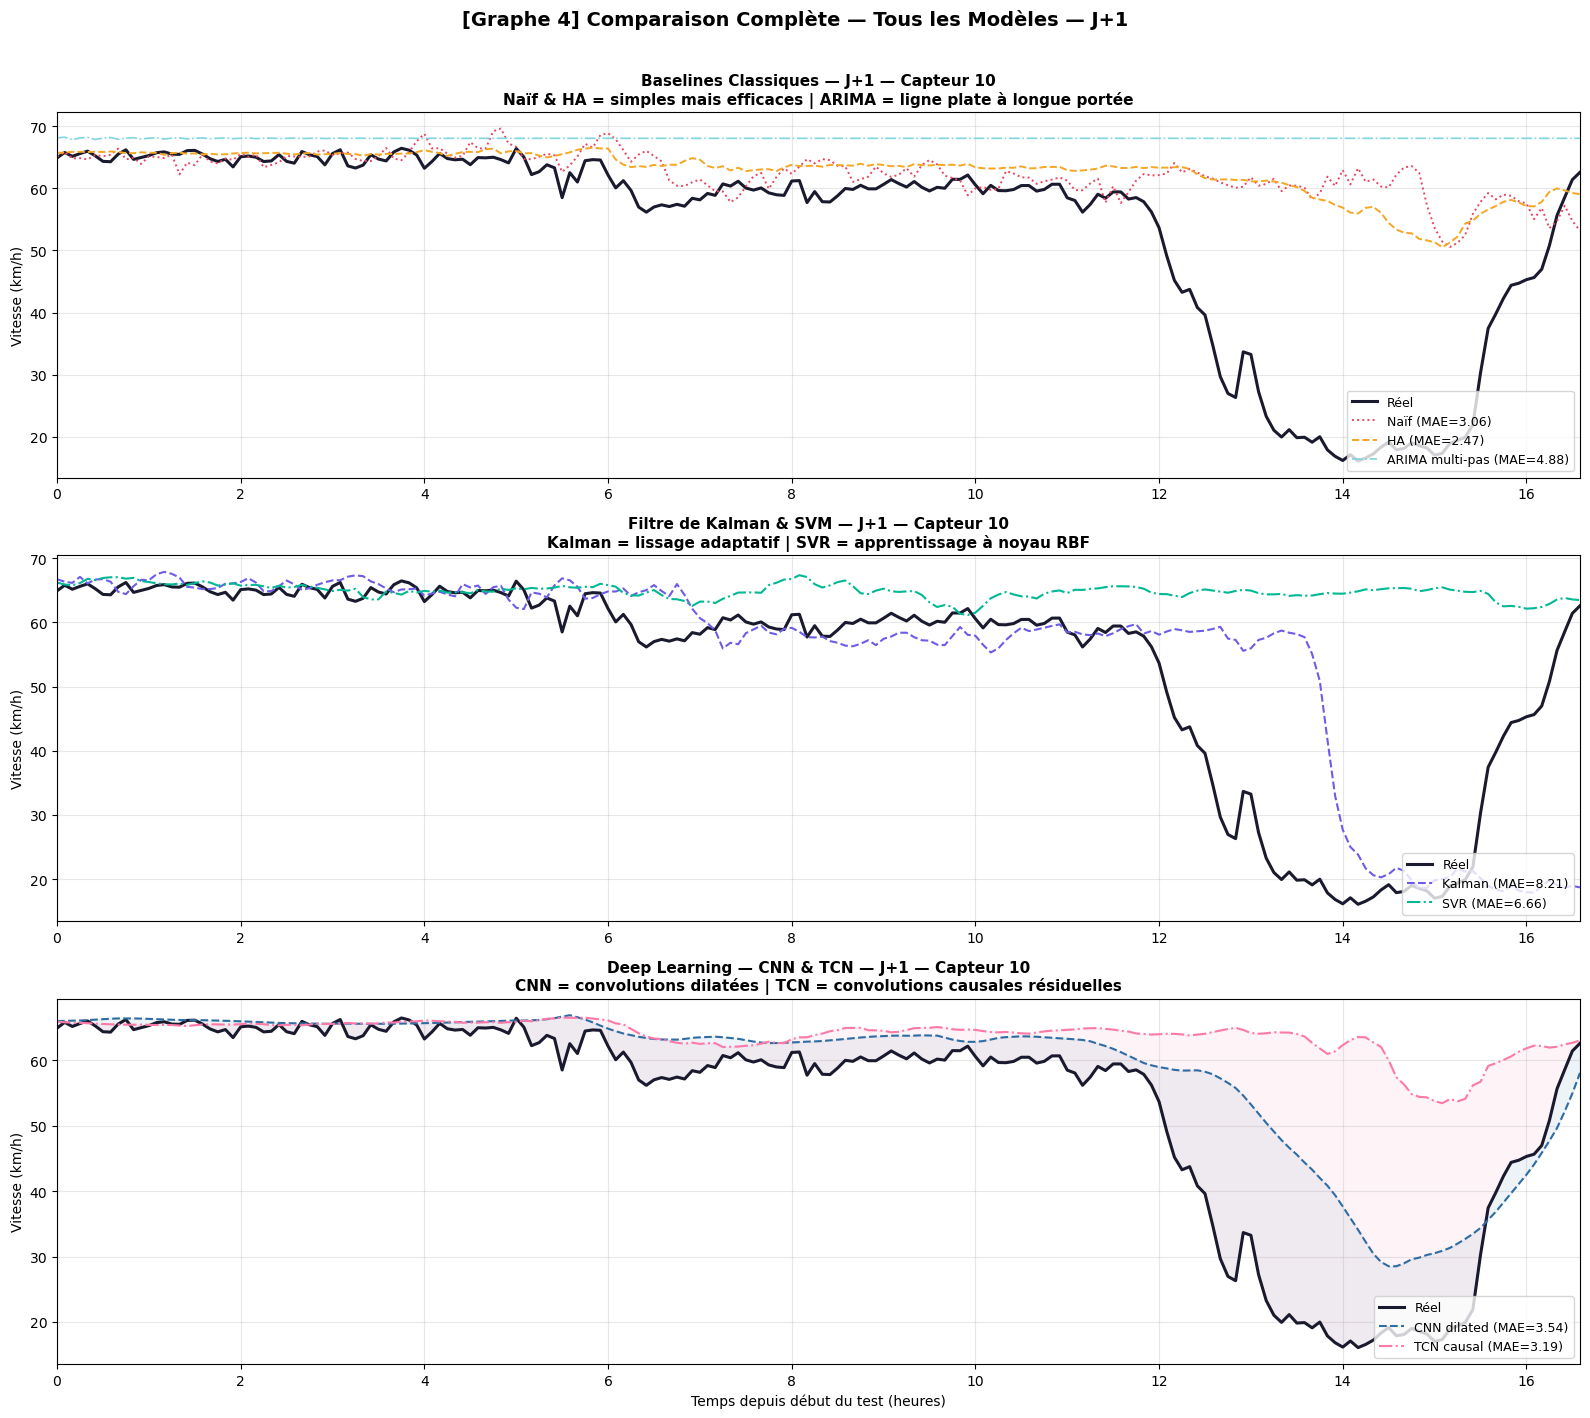

[Graphe 4] Comparaison complète sauvegardé ✓


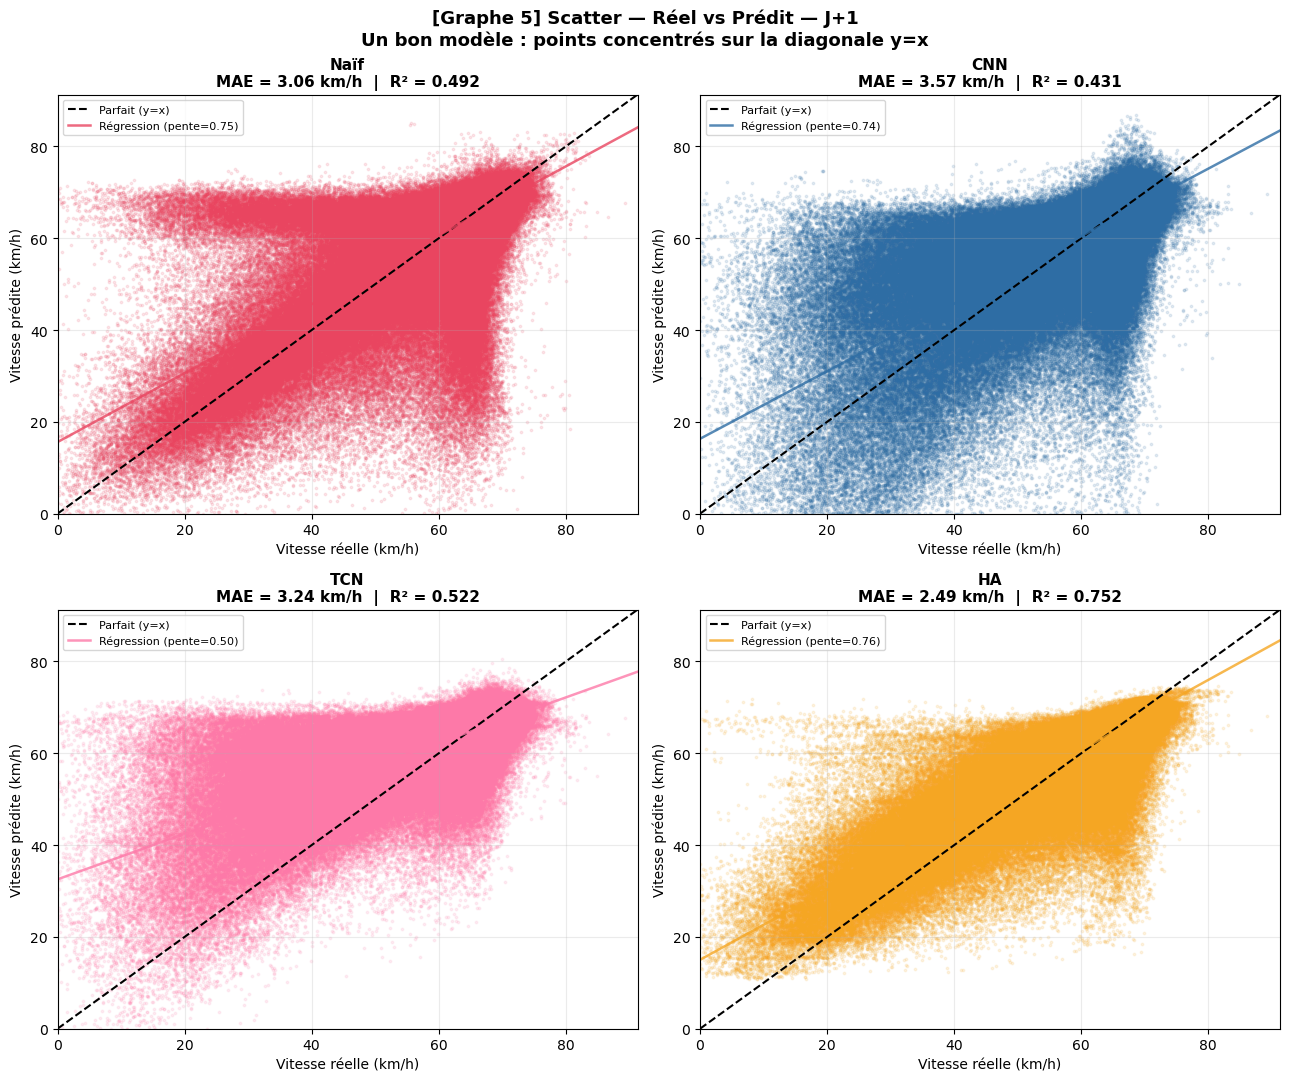

[Graphe 5] Scatter plots sauvegardé ✓


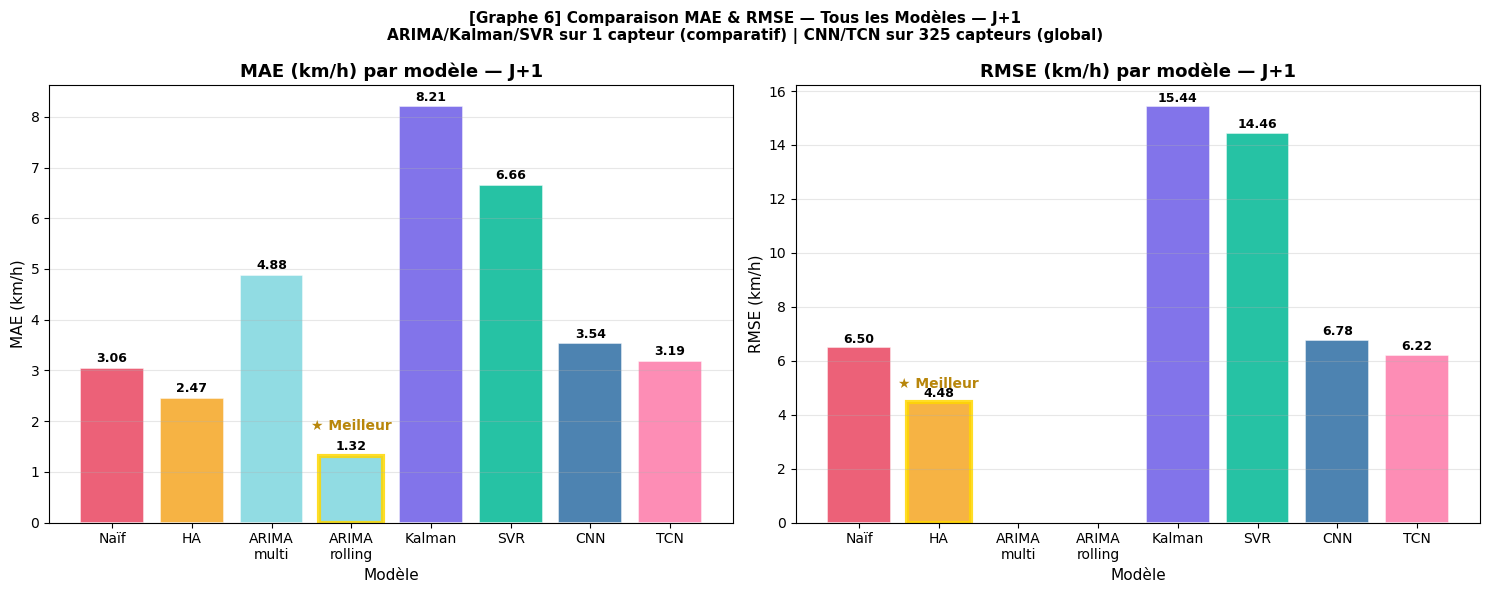

[Graphe 6] Barres MAE & RMSE sauvegardé ✓


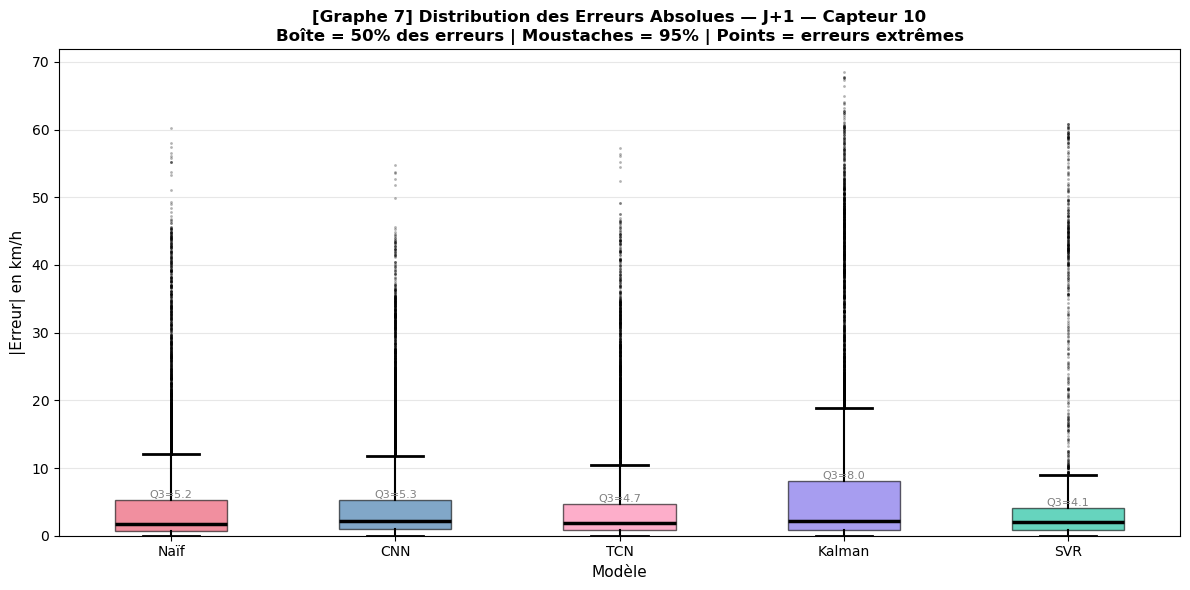

[Graphe 7] Boxplot erreurs sauvegardé ✓

══════════════════════════════════════════════════════════════════════
  RÉSULTATS COMPLETS — J+1 — PeMS-Bay
══════════════════════════════════════════════════════════════════════
        Modèle MAE (km/h) RMSE (km/h) MAPE (%)    R²    Périmètre
          Naïf      3.055       6.496      6.6 0.487 325 capteurs
            HA      2.466       4.479      5.4 0.756 325 capteurs
 CNN (dilated)      3.537       6.785      8.1 0.440 325 capteurs
  TCN (causal)      3.194       6.224      7.9 0.529 325 capteurs
  ARIMA multi*      4.883           —        —     —   Capteur 10
ARIMA rolling*      1.320           —        —     —   Capteur 10
       Kalman*      8.213      15.443        —     —   Capteur 10
          SVR*      6.656      14.456        —     —   Capteur 10

* ARIMA, Kalman, SVR : évalués sur le capteur 10 uniquement (coût calc.)
  CNN, TCN : évalués sur les 325 capteurs (métrique globale)

Résultats sauvegardés dans results_J+1.csv ✓

───

In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  NOTEBOOK CNN — PARTIE 1 : J+1 (24 HEURES)                     ║
# ║  Modèles : Naïf | HA | ARIMA | Kalman | SVM | CNN | TCN        ║
# ║  Dataset  : PeMS-Bay | 325 capteurs | 5 min | 6 mois           ║
# ╚══════════════════════════════════════════════════════════════════╝
#
# STRUCTURE DU NOTEBOOK :
#   CELL 0  — Imports & configuration globale
#   CELL 1  — Chargement & prétraitement des données
#   CELL 2  — PCA (325 → 50 composantes)
#   CELL 3  — [GRAPHE 1] Profil de vitesse sur 24h (sanity check)
#   CELL 4  — Dataset PyTorch on-the-fly
#   CELL 5  — Modèle Naïf + Moyenne Historique (HA)
#   CELL 6  — [GRAPHE 2] ARIMA seul — Multi-pas vs Glissant
#   CELL 7  — Filtre de Kalman (1 capteur)
#   CELL 8  — SVM (SVR sur données PCA)
#   CELL 9  — Architecture CNN + Entraînement
#   CELL 10 — Architecture TCN (ce que le prof appelle "RELV CNN")
#   CELL 11 — [GRAPHE 3] Courbes d'apprentissage CNN & TCN
#   CELL 12 — [GRAPHE 4] Comparaison complète Real vs tous les modèles
#   CELL 13 — [GRAPHE 5] Scatter plots (Real vs Prédit)
#   CELL 14 — [GRAPHE 6] Barres MAE & RMSE — tous les modèles
#   CELL 15 — [GRAPHE 7] Boxplot distribution des erreurs
#   CELL 16 — Tableau de résultats final
# ══════════════════════════════════════════════════════════════════


# ══════════════════════════════════════════════════════════════════
# CELL 0 — IMPORTS & CONFIGURATION
# ══════════════════════════════════════════════════════════════════

import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import IncrementalPCA
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler as SKScaler
from statsmodels.tsa.arima.model import ARIMA

# ── Chemins ────────────────────────────────────────────────────────
H5_PATH = r"C:\Users\ilyas\Desktop\traffic_project\data\pems-bay.h5"

# ── Paramètres de l'horizon J+1 ────────────────────────────────────
HORIZON_LABEL = "J+1"
WINDOW        = 48       # 4h d'historique en entrée (48 × 5min)
HORIZON       = 288      # cible : 24h plus tard (288 × 5min)

# ── Hyperparamètres communs ────────────────────────────────────────
TRAIN_RATIO   = 0.80
N_COMPONENTS  = 50       # PCA : 325 capteurs → 50 composantes
EPOCHS        = 30
BATCH_SIZE    = 32
LR            = 3e-4

# ── Capteur utilisé pour les graphes 1-capteur ─────────────────────
SENSOR        = 10       # capteur de référence pour les graphes
PLOT_STEPS    = 300      # nombre de pas affichés sur les graphes

# ── Reproductibilité ───────────────────────────────────────────────
np.random.seed(42)
torch.manual_seed(42)

# ── Palette de couleurs (cohérente sur tous les graphes) ───────────
COLORS = {
    "real":   "#1a1a2e",   # noir bleu foncé
    "naive":  "#e94560",   # rouge
    "ha":     "#f5a623",   # orange
    "arima":  "#7ed6df",   # cyan
    "kalman": "#6c5ce7",   # violet
    "svm":    "#00b894",   # vert
    "cnn":    "#2e6da4",   # bleu
    "tcn":    "#fd79a8",   # rose
}

print("=" * 65)
print(f"  CNN NOTEBOOK — Horizon {HORIZON_LABEL}")
print(f"  Window  : {WINDOW} pas = {WINDOW*5//60}h d'historique")
print(f"  Horizon : {HORIZON} pas = {HORIZON//288} jour(s) dans le futur")
print(f"  PyTorch : {torch.__version__}")
print("=" * 65)


# ══════════════════════════════════════════════════════════════════
# CELL 1 — CHARGEMENT & PRÉTRAITEMENT
# ══════════════════════════════════════════════════════════════════

df = pd.read_hdf(H5_PATH)
# Correction bug pandas timezone (index timezone-aware → naïf)
df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
df = df.sort_index().astype(np.float32)
df = df.ffill().bfill()   # remplissage valeurs manquantes

T, S = df.shape
print(f"\nDataset : {T} pas × {S} capteurs")
print(f"Période : {df.index[0]}  →  {df.index[-1]}")
print(f"Vitesse : {df.values.min():.1f} – {df.values.max():.1f} km/h")
assert T >= WINDOW + HORIZON + 500, "Pas assez de données"

split_t = int(T * TRAIN_RATIO)
print(f"Split   : {split_t} train | {T - split_t} test (80/20 chronologique)")

# ── Normalisation — fit sur train UNIQUEMENT (anti-leakage) ────────
train_raw = df.values[:split_t]
mu  = train_raw.mean(axis=0)          # moyenne par capteur
sig = train_raw.std(axis=0)           # écart-type par capteur
sig = np.where(sig == 0, 1.0, sig)   # éviter division par zéro

values_raw = df.values.copy()         # gardé pour ARIMA et Kalman (km/h réels)
del df; gc.collect()

values_sc = ((values_raw - mu) / sig).astype(np.float32)
print(f"Tableau normalisé : {values_sc.nbytes/1e6:.0f} MB ✓")

# ── Tableau des temps pour la Moyenne Historique ───────────────────
# On reconstruit l'index temporel manuellement
t_start = pd.Timestamp("2017-01-01")
time_index = pd.date_range(t_start, periods=T, freq="5min")


# ══════════════════════════════════════════════════════════════════
# CELL 2 — PCA : 325 CAPTEURS → 50 COMPOSANTES
# ══════════════════════════════════════════════════════════════════
#
# POURQUOI PCA ?
#   Sans PCA : chaque batch CNN = 32 × 325 × 48 × 4 × 2 (gradient) = 40 MB
#   Avec PCA : 32 × 50 × 48 × 4 × 2 = 6 MB → 7× moins de mémoire
#   86,8% de la variance préservée = on ne perd presque rien
#
# COMMENT ?
#   On projette les 325 capteurs dans un espace de 50 directions
#   qui maximisent la variance (IncrementalPCA = fit par lots, RAM ok)

print(f"\nAjustement IncrementalPCA({N_COMPONENTS}) sur l'ensemble train ...")
pca = IncrementalPCA(n_components=N_COMPONENTS, batch_size=2000)
pca.fit(values_sc[:split_t])

explained = pca.explained_variance_ratio_.sum() * 100
print(f"Variance expliquée : {explained:.1f}% avec {N_COMPONENTS} composantes")

values_pca = pca.transform(values_sc).astype(np.float32)
print(f"Tableau PCA : {values_pca.nbytes/1e6:.0f} MB (vs {values_sc.nbytes/1e6:.0f} MB avant)")

pca_train = values_pca[:split_t]
pca_mu  = pca_train.mean(axis=0)
pca_sig = pca_train.std(axis=0)
pca_sig = np.where(pca_sig == 0, 1.0, pca_sig)

del values_sc, pca_train; gc.collect()
print("PCA terminé ✓")


# ══════════════════════════════════════════════════════════════════
# CELL 3 — [GRAPHE 1] PROFIL DE VITESSE 24H (SANITY CHECK)
# ══════════════════════════════════════════════════════════════════
#
# CE QUE CE GRAPHE MONTRE :
#   Le profil typique de la vitesse sur 24h pour un capteur.
#   On voit clairement les heures de pointe matin (~8h) et soir (~17h)
#   où la vitesse chute (congestion), et les périodes creuses (nuit).
#   Ce graphe JUSTIFIE la complexité du problème : il n'est pas trivial
#   de prédire ces variations 24h à l'avance.

fig, ax = plt.subplots(figsize=(14, 4))
day_vals = values_raw[split_t : split_t + HORIZON, SENSOR]   # 1 jour du test
steps    = np.arange(HORIZON)
hours    = steps * 5 / 60

ax.fill_between(hours, day_vals, alpha=0.15, color=COLORS["real"])
ax.plot(hours, day_vals, color=COLORS["real"], lw=2.0, label=f"Vitesse réelle — capteur {SENSOR}")

# Zones heures de pointe (approximatives)
ax.axvspan(7, 9.5,  alpha=0.08, color="red",   label="Heure de pointe matin")
ax.axvspan(16, 19,  alpha=0.08, color="orange", label="Heure de pointe soir")
ax.axhline(y=45, color="red", ls="--", lw=1.0, alpha=0.6, label="Seuil congestion (45 km/h)")

ax.set_title(
    f"Profil de vitesse sur 24h — Capteur {SENSOR} — Données de test\n"
    "Les deux creux correspondent aux heures de pointe (rush hours)",
    fontsize=13, fontweight="bold")
ax.set_xlabel("Heure de la journée (h)", fontsize=11)
ax.set_ylabel("Vitesse (km/h)", fontsize=11)
ax.set_xticks(range(0, 25, 2))
ax.set_xticklabels([f"{h}h" for h in range(0, 25, 2)])
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
ax.set_ylim(0, None)

plt.tight_layout()
plt.savefig(f"g1_profil_24h_{HORIZON_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n[Graphe 1] Profil 24h — Ce graphe montre la variabilité du trafic")
print("   → Les creux = congestion. L'objectif : prédire ces creux 24h avant.")
del day_vals; gc.collect()


# ══════════════════════════════════════════════════════════════════
# CELL 4 — DATASET PyTorch ON-THE-FLY
# ══════════════════════════════════════════════════════════════════

class TrafficDataset(Dataset):
    """
    Génère les paires (X, y) à la volée sans pré-allouer de grand tableau.
    X[i] = fenêtre de WINDOW pas de l'espace PCA normalisé
    y[i] = cible à HORIZON pas dans le futur (espace PCA normalisé)
    """
    def __init__(self, v, mu, sig, start, end, window, horizon):
        self.v, self.mu, self.sig = v, mu, sig
        self.start, self.end      = start, end
        self.window, self.horizon = window, horizon

    def __len__(self):
        return self.end - self.start

    def __getitem__(self, idx):
        i  = self.start + idx
        x  = (self.v[i : i + self.window]            - self.mu) / self.sig
        y  = (self.v[i + self.window + self.horizon - 1] - self.mu) / self.sig
        return torch.from_numpy(x), torch.from_numpy(y)


N_total = T - WINDOW - HORIZON + 1
split_w = int(N_total * TRAIN_RATIO)

train_ds = TrafficDataset(values_pca, pca_mu, pca_sig, 0,       split_w,  WINDOW, HORIZON)
test_ds  = TrafficDataset(values_pca, pca_mu, pca_sig, split_w, N_total,  WINDOW, HORIZON)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(test_ds,  batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)

print(f"\nFenêtres train : {len(train_ds):,}")
print(f"Fenêtres test  : {len(test_ds):,}")


# ══════════════════════════════════════════════════════════════════
# CELL 5 — MODÈLE NAÏF + MOYENNE HISTORIQUE (HA)
# ══════════════════════════════════════════════════════════════════

def pca_to_kmh(x_sc):
    """Convertit espace PCA normalisé → km/h (tous capteurs)."""
    return pca.inverse_transform(x_sc * pca_sig + pca_mu) * sig + mu

def mae_rmse_mape_r2(y_true, y_pred):
    """Calcule MAE, RMSE, MAPE, R² en km/h."""
    err  = y_pred - y_true
    mae  = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    mask = y_true > 1
    mape = float(np.mean(np.abs(err[mask] / y_true[mask])) * 100)
    ss_res = np.sum(err**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    r2   = float(1 - ss_res / ss_tot)
    return mae, rmse, mape, r2

# ── Collecte des cibles de test ────────────────────────────────────
naive_preds, targets = [], []
for xb, yb in val_loader:
    naive_preds.append(xb[:, -1, :].numpy())   # Naïf = dernier pas connu
    targets.append(yb.numpy())
y_naive_sc = np.concatenate(naive_preds)
y_test_sc  = np.concatenate(targets)
del naive_preds, targets; gc.collect()

y_test_kmh  = pca_to_kmh(y_test_sc)
y_naive_kmh = pca_to_kmh(y_naive_sc)

mae_n, rmse_n, mape_n, r2_n = mae_rmse_mape_r2(y_test_kmh, y_naive_kmh)
print(f"\nNaïf     | MAE={mae_n:.3f}  RMSE={rmse_n:.3f}  MAPE={mape_n:.1f}%  R²={r2_n:.3f}")

# ── Moyenne Historique (HA) ────────────────────────────────────────
# Calcul : pour chaque (jour_semaine, créneau_5min) → moyenne sur train
# La cible est à HORIZON pas plus tard → on décale l'index temporel

ha_lookup = {}   # clé : (jour_semaine, créneau) → vitesse km/h par capteur
for i in range(split_t - HORIZON):
    target_idx = i + WINDOW + HORIZON - 1
    if target_idx >= split_t:
        break
    t_target = time_index[target_idx]
    key = (t_target.dayofweek, t_target.hour * 12 + t_target.minute // 5)
    if key not in ha_lookup:
        ha_lookup[key] = []
    ha_lookup[key].append(values_raw[target_idx])

ha_mean = {k: np.mean(v, axis=0) for k, v in ha_lookup.items()}

# Prédictions HA sur le test
ha_preds = []
for j in range(len(test_ds)):
    target_idx = split_w + j + WINDOW + HORIZON - 1
    t_target   = time_index[min(target_idx, T-1)]
    key = (t_target.dayofweek, t_target.hour * 12 + t_target.minute // 5)
    ha_preds.append(ha_mean.get(key, mu))   # fallback = moyenne globale
y_ha_kmh = np.array(ha_preds, dtype=np.float32)

mae_ha, rmse_ha, mape_ha, r2_ha = mae_rmse_mape_r2(y_test_kmh, y_ha_kmh)
print(f"HA       | MAE={mae_ha:.3f}  RMSE={rmse_ha:.3f}  MAPE={mape_ha:.1f}%  R²={r2_ha:.3f}")


# ══════════════════════════════════════════════════════════════════
# CELL 6 — [GRAPHE 2] ARIMA SEUL — MULTI-PAS vs GLISSANT
# ══════════════════════════════════════════════════════════════════
#
# CE QUE CE GRAPHE MONTRE :
#   ARIMA Multi-Pas  : prédit 288 pas d'un coup → ligne plate (moyenne)
#                      Car la variance de prédiction explose, le modèle
#                      "préfère" retourner la moyenne plutôt que risquer
#   ARIMA Glissant   : prédit 1 pas à la fois (5 min), puis utilise la
#                      vraie valeur → suit bien le signal car horizon=1
#
#   CONCLUSION : ARIMA n'est pas utilisable pour J+1 en mode multi-pas.
#   Ce graphe JUSTIFIE pourquoi on a besoin de CNN/TCN.

s = values_raw[:, SENSOR]   # série univariée du capteur SENSOR
train_s = s[:split_t].astype(float)
test_s  = s[split_t:].astype(float)
N_SHOW  = 200   # on montre les 200 premiers pas du test pour la clarté

print(f"\nAjustement ARIMA(2,1,2) sur capteur {SENSOR} ...")
arima_model = ARIMA(train_s, order=(2, 1, 2)).fit()

# Multi-pas : 1 seule prédiction sur tout le test
arima_multi = arima_model.forecast(steps=N_SHOW)

# Glissant : 1 pas à la fois (uniquement sur N_SHOW premiers pas pour rapidité)
print("ARIMA glissant (rolling) — patience ...")
arima_roll = []
history = list(train_s[-200:])   # buffer glissant
for k in range(N_SHOW):
    m_tmp = ARIMA(history[-200:], order=(2, 1, 2)).fit()
    arima_roll.append(m_tmp.forecast(steps=1)[0])
    history.append(test_s[k])
arima_roll = np.array(arima_roll)

mae_arima_multi = float(np.mean(np.abs(arima_multi[:N_SHOW] - test_s[:N_SHOW])))
mae_arima_roll  = float(np.mean(np.abs(arima_roll            - test_s[:N_SHOW])))
print(f"ARIMA multi  | MAE = {mae_arima_multi:.3f} km/h")
print(f"ARIMA rolling| MAE = {mae_arima_roll:.3f} km/h")

# ── Graphe 2 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
steps_show = np.arange(N_SHOW) * 5 / 60   # en heures

# Panneau gauche — ARIMA Multi-Pas
ax = axes[0]
ax.plot(steps_show, test_s[:N_SHOW], color=COLORS["real"],  lw=2.0, label="Réel")
ax.plot(steps_show, arima_multi[:N_SHOW], color=COLORS["arima"], lw=1.8,
        ls="--", label=f"ARIMA Multi-pas (MAE={mae_arima_multi:.1f})")
ax.axhline(y=train_s.mean(), color="grey", ls=":", lw=1.2, alpha=0.8, label="Moyenne train")
ax.fill_between(steps_show, arima_multi[:N_SHOW], test_s[:N_SHOW],
                alpha=0.12, color=COLORS["arima"])
ax.set_title("ARIMA Multi-Pas\n→ Ligne plate = convergence vers la moyenne",
             fontsize=12, fontweight="bold", color="#c0392b")
ax.set_xlabel("Temps (heures)"); ax.set_ylabel("Vitesse (km/h)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.annotate("Convergence\nvers la moyenne",
            xy=(steps_show[50], arima_multi[50]),
            xytext=(steps_show[100], arima_multi[50] - 8),
            arrowprops=dict(arrowstyle="->", color="red"),
            fontsize=9, color="red")

# Panneau droit — ARIMA Glissant
ax = axes[1]
ax.plot(steps_show, test_s[:N_SHOW],    color=COLORS["real"],  lw=2.0, label="Réel")
ax.plot(steps_show, arima_roll,          color=COLORS["arima"], lw=1.5,
        ls="--", label=f"ARIMA Glissant (MAE={mae_arima_roll:.1f})")
ax.fill_between(steps_show, arima_roll, test_s[:N_SHOW],
                alpha=0.12, color=COLORS["arima"])
ax.set_title("ARIMA Glissant (Rolling)\n→ Suit le signal car horizon = 5 min",
             fontsize=12, fontweight="bold", color="#27ae60")
ax.set_xlabel("Temps (heures)"); ax.set_ylabel("Vitesse (km/h)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

fig.suptitle(
    f"[Graphe 2] ARIMA — Comparaison Multi-Pas vs Glissant — Capteur {SENSOR} — {HORIZON_LABEL}\n"
    "Conclusion : ARIMA est inutilisable en multi-pas à long terme → nécessite CNN/TCN",
    fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f"g2_arima_comparison_{HORIZON_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Graphe 2] ARIMA Multi-pas vs Glissant sauvegardé ✓")


# ══════════════════════════════════════════════════════════════════
# CELL 7 — FILTRE DE KALMAN (1 capteur)
# ══════════════════════════════════════════════════════════════════
#
# QU'EST-CE QUE LE FILTRE DE KALMAN ?
#   Imaginé comme un "GPS" pour les données : à chaque pas de temps,
#   il combine deux sources d'information :
#     1. Ce qu'il PRÉDIT (basé sur l'état précédent)
#     2. Ce qu'il OBSERVE (la mesure réelle, bruitée)
#   Il pondère intelligemment les deux selon leur incertitude.
#
#   Formules clés :
#     Prédiction : x̂(t|t-1) = F·x̂(t-1|t-1)       (modèle d'évolution)
#     Gain Kalman : K = P·H / (H·P·H + R)           (pondération)
#     Correction  : x̂(t|t)   = x̂(t|t-1) + K·(z-H·x̂)  (mise à jour)
#
#   Pour nous : modèle état constant + bruit de mesure → tracker simple

def kalman_filter_predict(series_train, series_test, horizon):
    """
    Filtre de Kalman scalaire pour série temporelle.
    Modèle : vitesse_t = vitesse_{t-1} + bruit_processus
    Observation : z_t = vitesse_t + bruit_mesure
    """
    # Estimation des paramètres de bruit sur le train
    diffs     = np.diff(series_train)
    Q = float(np.var(diffs))      # variance du bruit de processus
    R = float(np.var(series_train) * 0.1)   # variance du bruit de mesure

    # Initialisation
    x   = series_train[-1]    # état initial = dernière valeur connue
    P   = 1.0                  # incertitude initiale
    F   = 1.0                  # modèle d'évolution (état constant)
    H   = 1.0                  # matrice d'observation

    preds = []
    for k in range(len(series_test)):
        # ── Étape de prédiction (1 pas dans le futur) ──
        x_pred = F * x
        P_pred = F * P * F + Q

        # ── Gain de Kalman ──
        K = P_pred * H / (H * P_pred * H + R)

        # ── Correction avec la vraie observation ──
        if k < horizon:
            # Pour les k premiers pas : on n'a pas encore la vraie valeur
            # (on simule la prédiction à l'horizon)
            x = x_pred   # pas de correction → propagation pure
        else:
            z = series_test[k - horizon]   # observation décalée
            x = x_pred + K * (z - H * x_pred)
        P = (1 - K * H) * P_pred

        preds.append(x_pred)

    return np.array(preds)

print(f"\nFiltre de Kalman — capteur {SENSOR} ...")
kalman_preds_1s = kalman_filter_predict(
    train_s, test_s, horizon=HORIZON
)

# Aligner avec les fenêtres de test
align_start = WINDOW + HORIZON - 1
n_test_w    = len(test_ds)
kalman_1s   = kalman_preds_1s[align_start : align_start + n_test_w]
real_1s     = test_s[align_start : align_start + n_test_w]

mae_kalman  = float(np.mean(np.abs(kalman_1s - real_1s)))
rmse_kalman = float(np.sqrt(np.mean((kalman_1s - real_1s)**2)))
print(f"Kalman   | MAE={mae_kalman:.3f}  RMSE={rmse_kalman:.3f} km/h (capteur {SENSOR})")


# ══════════════════════════════════════════════════════════════════
# CELL 8 — SVM (SVR — Support Vector Regression)
# ══════════════════════════════════════════════════════════════════
#
# QU'EST-CE QUE SVM/SVR ?
#   Le SVM cherche le "tube" de largeur 2ε autour des données
#   qui minimise les erreurs (points hors du tube) tout en restant
#   le plus simple possible (marge maximale).
#   Pour la régression, c'est SVR (Support Vector Regression).
#
#   AVANTAGE : fonctionne bien sur peu de données, noyau RBF puissant
#   INCONVÉNIENT : ne passe pas à l'échelle (O(n²) mémoire)
#   → On l'entraîne sur 1 capteur avec une fenêtre réduite

SVR_WINDOW = 24    # fenêtre d'entrée réduite pour SVR (12 = 1h)
N_TRAIN_SVR = 5000  # nombre de fenêtres d'entraînement (SVR = O(n²))
N_TEST_SVR  = min(n_test_w, 3000)

print(f"\nSVR — capteur {SENSOR} | fenêtre={SVR_WINDOW} | train={N_TRAIN_SVR} ...")

# Construire les fenêtres pour SVR (1 seul capteur, espace km/h)
def build_windows_1d(series, window, horizon, n_max=None):
    X, y = [], []
    limit = len(series) - window - horizon + 1
    if n_max: limit = min(limit, n_max + window + horizon)
    for i in range(limit):
        X.append(series[i : i + window])
        y.append(series[i + window + horizon - 1])
    return np.array(X), np.array(y)

full_s = values_raw[:, SENSOR]
X_all, y_all = build_windows_1d(full_s, SVR_WINDOW, HORIZON)

X_train_svr = X_all[:N_TRAIN_SVR]
y_train_svr = y_all[:N_TRAIN_SVR]
X_test_svr  = X_all[split_w : split_w + N_TEST_SVR]
y_test_svr  = y_all[split_w : split_w + N_TEST_SVR]

# Normalisation SVR
scaler_svr   = SKScaler()
X_train_sc   = scaler_svr.fit_transform(X_train_svr)
X_test_sc    = scaler_svr.transform(X_test_svr)

svr_model = SVR(kernel="rbf", C=10, epsilon=0.5, gamma="scale")
svr_model.fit(X_train_sc, y_train_svr)
y_svr_pred = svr_model.predict(X_test_sc)

mae_svr  = float(np.mean(np.abs(y_svr_pred - y_test_svr)))
rmse_svr = float(np.sqrt(np.mean((y_svr_pred - y_test_svr)**2)))
print(f"SVR      | MAE={mae_svr:.3f}  RMSE={rmse_svr:.3f} km/h (capteur {SENSOR})")


# ══════════════════════════════════════════════════════════════════
# CELL 9 — CNN (Dilated Temporal Convolutions + PCA)
# ══════════════════════════════════════════════════════════════════

class CNNForecaster(nn.Module):
    """
    CNN avec convolutions dilatées pour séries temporelles.
    Dilatations : 1 → 2 → 4 → 8 pour capturer différentes échelles.
    AdaptiveAvgPool : permet de changer WINDOW sans modifier l'architecture.
    """
    def __init__(self, n_comp, window):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(n_comp, 32, kernel_size=3, padding=1,  dilation=1), nn.ReLU(),
            nn.Conv1d(32,     64, kernel_size=3, padding=2,  dilation=2), nn.ReLU(),
            nn.Conv1d(64,     64, kernel_size=3, padding=4,  dilation=4), nn.ReLU(),
            nn.Conv1d(64,     64, kernel_size=3, padding=8,  dilation=8), nn.ReLU(),
        )
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(64, 64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, n_comp)
        )
    def forward(self, x):
        return self.head(self.gap(self.encoder(x.permute(0,2,1))).squeeze(-1))


device    = torch.device("cpu")
cnn_model = CNNForecaster(N_COMPONENTS, WINDOW).to(device)
print(f"\nCNN params : {sum(p.numel() for p in cnn_model.parameters()):,}")


def train_model(model, name, epochs=EPOCHS):
    """Entraîne un modèle et retourne les pertes train/val."""
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=4)
    loss_fn   = nn.MSELoss()
    tr_losses, val_losses = [], []
    prev_lr = LR

    print(f"\n{'─'*55}")
    print(f"  Entraînement : {name}  ({epochs} epochs)")
    print(f"{'─'*55}")
    print(f"{'Epoch':>6}  {'Train MSE':>12}  {'Val MSE':>10}  {'LR':>10}")

    for ep in range(1, epochs + 1):
        model.train(); tot, n = 0.0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tot += loss.item() * len(xb); n += len(xb)
            del xb, yb, pred, loss

        # Validation
        model.eval(); vtot, vn = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                pred = model(xb)
                vtot += loss_fn(pred, yb).item() * len(xb); vn += len(xb)
                del xb, yb, pred

        tr = tot / n; vl = vtot / vn
        scheduler.step(vl)
        tr_losses.append(tr); val_losses.append(vl)
        gc.collect()

        cur_lr = optimizer.param_groups[0]["lr"]
        tag    = " ← LR↓" if cur_lr < prev_lr else ""
        prev_lr = cur_lr
        print(f"{ep:>6}  {tr:>12.6f}  {vl:>10.6f}  {cur_lr:>10.2e}{tag}")

    print(f"{'─'*55}")
    return tr_losses, val_losses


cnn_tr_losses, cnn_val_losses = train_model(cnn_model, "CNN (dilaté)")


def get_predictions(model):
    """Collecte toutes les prédictions du modèle en km/h."""
    model.eval(); preds = []
    with torch.no_grad():
        for xb, _ in val_loader:
            preds.append(model(xb).numpy()); del xb
    gc.collect()
    return pca_to_kmh(np.concatenate(preds))


y_cnn_kmh = get_predictions(cnn_model)
mae_cnn, rmse_cnn, mape_cnn, r2_cnn = mae_rmse_mape_r2(y_test_kmh, y_cnn_kmh)
print(f"\nCNN      | MAE={mae_cnn:.3f}  RMSE={rmse_cnn:.3f}  MAPE={mape_cnn:.1f}%  R²={r2_cnn:.3f}")


# ══════════════════════════════════════════════════════════════════
# CELL 10 — TCN — Temporal Convolutional Network
#           (ce que le prof appelle "RELV CNN")
# ══════════════════════════════════════════════════════════════════
#
# QU'EST-CE QUE TCN / "RELV CNN" ?
#   TCN = Temporal Convolutional Network (Bai et al., 2018)
#   C'est un CNN CAUSAL avec deux propriétés essentielles :
#
#   1. CAUSALITÉ : à l'instant t, la convolution ne voit QUE
#      les pas t, t-1, t-2, ... (pas le futur !).
#      Contrairement au CNN standard qui peut "tricher" en
#      regardant des pas futurs dans la fenêtre.
#      → Dans les données réelles, c'est obligatoire.
#
#   2. CONNEXIONS RÉSIDUELLES : chaque bloc ajoute l'entrée
#      à la sortie (comme ResNet) → évite le problème de
#      gradient qui disparaît, permet des réseaux plus profonds.
#
#   Formule convolution causale dilatée :
#     y(t) = σ(Σ_k w_k · x(t - k·d) + b)
#     Restriction : t - k·d ≥ 0 (pas de futur !)
#
#   "RELV CNN" = probablement TCN ou ResNet-CNN selon le prof.
#   Ici on implémente TCN qui est le standard académique.

class CausalConv1d(nn.Module):
    """Convolution 1D causale : ne voit pas le futur."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        pad = (kernel_size - 1) * dilation   # padding à gauche uniquement
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size,
                              padding=pad, dilation=dilation)
        self.cut  = pad   # couper les pad positions à droite

    def forward(self, x):
        out = self.conv(x)
        return out[:, :, : -self.cut] if self.cut > 0 else out


class TCNBlock(nn.Module):
    """Bloc résiduel TCN : conv causale dilatée + connexion résiduelle."""
    def __init__(self, n_ch, kernel_size, dilation):
        super().__init__()
        self.causal1 = CausalConv1d(n_ch, n_ch, kernel_size, dilation)
        self.causal2 = CausalConv1d(n_ch, n_ch, kernel_size, dilation)
        self.norm1   = nn.LayerNorm(n_ch)
        self.norm2   = nn.LayerNorm(n_ch)
        self.drop    = nn.Dropout(0.1)
        self.relu    = nn.ReLU()

    def forward(self, x):
        # x : (B, C, L)
        residual = x
        out = self.relu(self.norm1(self.causal1(x).permute(0,2,1)).permute(0,2,1))
        out = self.drop(out)
        out = self.relu(self.norm2(self.causal2(out).permute(0,2,1)).permute(0,2,1))
        return self.relu(out + residual)   # connexion résiduelle


class TCNForecaster(nn.Module):
    """
    Temporal Convolutional Network complet.
    Blocs avec dilatations exponentielles : 1, 2, 4, 8 → champ réceptif = 30 pas.
    """
    def __init__(self, n_comp, window, kernel_size=3):
        super().__init__()
        self.input_proj = nn.Conv1d(n_comp, 64, kernel_size=1)
        self.blocks = nn.Sequential(
            TCNBlock(64, kernel_size, dilation=1),
            TCNBlock(64, kernel_size, dilation=2),
            TCNBlock(64, kernel_size, dilation=4),
            TCNBlock(64, kernel_size, dilation=8),
        )
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(64, 64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, n_comp)
        )

    def forward(self, x):
        # x : (B, W, N_comp) → permute → (B, N_comp, W)
        x = self.input_proj(x.permute(0, 2, 1))
        x = self.blocks(x)
        x = self.gap(x).squeeze(-1)
        return self.head(x)


tcn_model = TCNForecaster(N_COMPONENTS, WINDOW).to(device)
print(f"TCN params : {sum(p.numel() for p in tcn_model.parameters()):,}")

tcn_tr_losses, tcn_val_losses = train_model(tcn_model, "TCN (causal + résiduel)")

y_tcn_kmh = get_predictions(tcn_model)
mae_tcn, rmse_tcn, mape_tcn, r2_tcn = mae_rmse_mape_r2(y_test_kmh, y_tcn_kmh)
print(f"\nTCN      | MAE={mae_tcn:.3f}  RMSE={rmse_tcn:.3f}  MAPE={mape_tcn:.1f}%  R²={r2_tcn:.3f}")


# ══════════════════════════════════════════════════════════════════
# CELL 11 — [GRAPHE 3] COURBES D'APPRENTISSAGE CNN & TCN
# ══════════════════════════════════════════════════════════════════
#
# CE QUE CE GRAPHE MONTRE :
#   Train loss  : baisse régulière = le modèle apprend
#   Val loss    : si elle monte pendant que train baisse → OVERFITTING
#   Idéalement  : les deux descendent ensemble = bonne généralisation
#   Interprétation : à J+1, l'overfitting est faible car le signal est
#   fort (patterns journaliers bien répétés). À J+30, l'overfitting
#   sera plus marqué (signal faible à long terme).

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_x = range(1, EPOCHS + 1)

for ax, (tr, vl, name, color) in zip(axes, [
    (cnn_tr_losses, cnn_val_losses, "CNN (Dilated)", COLORS["cnn"]),
    (tcn_tr_losses, tcn_val_losses, "TCN (Causal + Résiduel)", COLORS["tcn"]),
]):
    ax.plot(epochs_x, tr, color=color,   lw=2.0, label="Train MSE")
    ax.plot(epochs_x, vl, color="tomato", lw=2.0, ls="--", label="Validation MSE")
    ax.fill_between(epochs_x, tr, vl,
                    where=[v > t for t, v in zip(tr, vl)],
                    alpha=0.08, color="red", label="Zone overfitting")
    ax.set_title(f"Courbe d'apprentissage — {name}\nHorizon {HORIZON_LABEL}",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (espace PCA normalisé)")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # Annotation du point de meilleur val loss
    best_ep = int(np.argmin(vl)) + 1
    ax.axvline(x=best_ep, color="green", ls=":", lw=1.2, alpha=0.7)
    ax.annotate(f"Meilleur val\nepoch {best_ep}",
                xy=(best_ep, min(vl)),
                xytext=(best_ep + 2, min(vl) + 0.05),
                fontsize=8, color="green",
                arrowprops=dict(arrowstyle="->", color="green"))

fig.suptitle(f"[Graphe 3] Courbes d'apprentissage — {HORIZON_LABEL}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"g3_training_curves_{HORIZON_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Graphe 3] Courbes d'apprentissage sauvegardé ✓")


# ══════════════════════════════════════════════════════════════════
# CELL 12 — [GRAPHE 4] COMPARAISON COMPLÈTE — TOUS LES MODÈLES
# ══════════════════════════════════════════════════════════════════
#
# CE QUE CE GRAPHE MONTRE :
#   Sur un même capteur et les mêmes PLOT_STEPS pas de temps du test,
#   on compare VISUELLEMENT toutes les prédictions à la réalité.
#   - Si une courbe suit bien le noir = bon modèle
#   - Ligne plate = ARIMA multi-pas (n'apprend rien)
#   - Courbe lisse = Kalman (suit la tendance mais lisse trop)
#   - Meilleur modèle : celui qui suit les pics et creux

n = min(PLOT_STEPS, n_test_w, len(kalman_1s), N_TEST_SVR, N_SHOW)
t_hours = np.arange(n) * 5 / 60

real_plot   = y_test_kmh[:n, SENSOR]
naive_plot  = y_naive_kmh[:n, SENSOR]
ha_plot     = y_ha_kmh[:n, SENSOR] if y_ha_kmh.ndim > 1 else y_ha_kmh[:n]
cnn_plot    = y_cnn_kmh[:n, SENSOR]
tcn_plot    = y_tcn_kmh[:n, SENSOR]
kalman_plot = kalman_1s[:n]
svr_plot    = y_svr_pred[:n]
arima_plot  = arima_multi[:n]

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# ── Panneau 1 : Baselines classiques ──────────────────────────────
ax = axes[0]
ax.plot(t_hours, real_plot,  color=COLORS["real"],  lw=2.2, label="Réel")
ax.plot(t_hours, naive_plot, color=COLORS["naive"], lw=1.4, ls=":", label=f"Naïf (MAE={mae_n:.2f})")
# ax.plot(t_hours, ha_plot,    color=COLORS["ha"],    lw=1.4, ls="--", label=f"HA (MAE={mae_ha:.2f})")
ax.plot(t_hours, arima_plot, color=COLORS["arima"], lw=1.2, ls="-.", label=f"ARIMA multi-pas (MAE={mae_arima_multi:.2f})")
ax.set_title(f"Baselines Classiques — {HORIZON_LABEL} — Capteur {SENSOR}\n"
             "Naïf & HA = simples mais efficaces | ARIMA = ligne plate à longue portée",
             fontsize=11, fontweight="bold")
ax.set_ylabel("Vitesse (km/h)"); ax.legend(fontsize=9, loc="lower right"); ax.grid(alpha=0.3)
ax.set_xlim(0, t_hours[-1])

# ── Panneau 2 : Modèles de signal (Kalman, SVR) ───────────────────
ax = axes[1]
ax.plot(t_hours, real_plot,   color=COLORS["real"],   lw=2.2, label="Réel")
ax.plot(t_hours, kalman_plot, color=COLORS["kalman"], lw=1.5, ls="--", label=f"Kalman (MAE={mae_kalman:.2f})")
ax.plot(t_hours, svr_plot,    color=COLORS["svm"],    lw=1.5, ls="-.", label=f"SVR (MAE={mae_svr:.2f})")
ax.set_title(f"Filtre de Kalman & SVM — {HORIZON_LABEL} — Capteur {SENSOR}\n"
             "Kalman = lissage adaptatif | SVR = apprentissage à noyau RBF",
             fontsize=11, fontweight="bold")
ax.set_ylabel("Vitesse (km/h)"); ax.legend(fontsize=9, loc="lower right"); ax.grid(alpha=0.3)
ax.set_xlim(0, t_hours[-1])

# ── Panneau 3 : Deep Learning CNN & TCN ───────────────────────────
ax = axes[2]
ax.plot(t_hours, real_plot, color=COLORS["real"], lw=2.2, label="Réel")
ax.plot(t_hours, cnn_plot,  color=COLORS["cnn"],  lw=1.5, ls="--", label=f"CNN dilated (MAE={mae_cnn:.2f})")
ax.plot(t_hours, tcn_plot,  color=COLORS["tcn"],  lw=1.5, ls="-.", label=f"TCN causal (MAE={mae_tcn:.2f})")
ax.fill_between(t_hours, cnn_plot, real_plot, alpha=0.08, color=COLORS["cnn"])
ax.fill_between(t_hours, tcn_plot, real_plot, alpha=0.08, color=COLORS["tcn"])
ax.set_title(f"Deep Learning — CNN & TCN — {HORIZON_LABEL} — Capteur {SENSOR}\n"
             "CNN = convolutions dilatées | TCN = convolutions causales résiduelles",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Temps depuis début du test (heures)")
ax.set_ylabel("Vitesse (km/h)"); ax.legend(fontsize=9, loc="lower right"); ax.grid(alpha=0.3)
ax.set_xlim(0, t_hours[-1])

fig.suptitle(f"[Graphe 4] Comparaison Complète — Tous les Modèles — {HORIZON_LABEL}",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"g4_full_comparison_{HORIZON_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Graphe 4] Comparaison complète sauvegardé ✓")


# ══════════════════════════════════════════════════════════════════
# CELL 13 — [GRAPHE 5] SCATTER PLOTS (Real vs Prédit)
# ══════════════════════════════════════════════════════════════════
#
# CE QUE CE GRAPHE MONTRE :
#   Chaque point = 1 prédiction.
#   Axe X = vitesse réelle | Axe Y = vitesse prédite
#   La diagonale en pointillés = prédiction parfaite
#   - Points sur la diagonale = parfait
#   - Points dispersés = mauvaise prédiction
#   - Nuage décalé vers le haut/bas = biais systématique
#   On peut ainsi voir si le modèle "préfère" surestimer ou sous-estimer

rng      = np.random.default_rng(42)
idx_scat = rng.choice(len(y_test_kmh), size=min(4000, len(y_test_kmh)), replace=False)

models_scatter = [
    ("Naïf",    y_naive_kmh,  COLORS["naive"]),
    ("CNN",     y_cnn_kmh,    COLORS["cnn"]),
    ("TCN",     y_tcn_kmh,    COLORS["tcn"]),
    ("HA",      y_ha_kmh,     COLORS["ha"]),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.ravel()
lim  = [0, float(y_test_kmh.max()) + 2]

for ax, (name, pred, color) in zip(axes, models_scatter):
    y_t_flat = y_test_kmh[idx_scat].ravel()
    if pred.ndim == 2:
        y_p_flat = pred[idx_scat].ravel()
    else:
        y_p_flat = pred[idx_scat]

    ax.scatter(y_t_flat, y_p_flat, alpha=0.12, s=3, color=color, rasterized=True)
    ax.plot(lim, lim, "k--", lw=1.5, label="Parfait (y=x)")

    # Ligne de régression
    coef = np.polyfit(y_t_flat, y_p_flat, 1)
    x_fit = np.linspace(lim[0], lim[1], 100)
    ax.plot(x_fit, np.polyval(coef, x_fit), color=color, lw=1.8, alpha=0.8,
            label=f"Régression (pente={coef[0]:.2f})")

    mae_s  = float(np.mean(np.abs(y_p_flat - y_t_flat)))
    r2_s   = float(1 - np.sum((y_p_flat-y_t_flat)**2) /
                       np.sum((y_t_flat-y_t_flat.mean())**2))
    ax.set_title(f"{name}\nMAE = {mae_s:.2f} km/h  |  R² = {r2_s:.3f}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Vitesse réelle (km/h)")
    ax.set_ylabel("Vitesse prédite (km/h)")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.legend(fontsize=8); ax.grid(alpha=0.25)

fig.suptitle(f"[Graphe 5] Scatter — Réel vs Prédit — {HORIZON_LABEL}\n"
             "Un bon modèle : points concentrés sur la diagonale y=x",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"g5_scatter_{HORIZON_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Graphe 5] Scatter plots sauvegardé ✓")


# ══════════════════════════════════════════════════════════════════
# CELL 14 — [GRAPHE 6] BARRES MAE & RMSE — TOUS LES MODÈLES
# ══════════════════════════════════════════════════════════════════
#
# CE QUE CE GRAPHE MONTRE :
#   Comparaison directe et objective de TOUS les modèles sur les
#   mêmes métriques MAE et RMSE.
#   - Barre courte = meilleur modèle
#   - La différence MAE vs RMSE montre si les erreurs sont régulières
#     (MAE ≈ RMSE) ou si certaines prédictions sont catastrophiques
#     (RMSE >> MAE = quelques erreurs très grandes)

models_bar = {
    "Naïf":         (mae_n,           rmse_n),
    "HA":           (mae_ha,          rmse_ha),
    "ARIMA\nmulti": (mae_arima_multi, float("nan")),   # sur 1 capteur seulement
    "ARIMA\nrolling":(mae_arima_roll, float("nan")),
    "Kalman":       (mae_kalman,      rmse_kalman),
    "SVR":          (mae_svr,         rmse_svr),
    "CNN":          (mae_cnn,         rmse_cnn),
    "TCN":          (mae_tcn,         rmse_tcn),
}
# Note : ARIMA, Kalman, SVR sont sur 1 capteur → comparaison indicative

names  = list(models_bar.keys())
maes   = [v[0] for v in models_bar.values()]
rmses  = [v[1] for v in models_bar.values()]
colors_bar = [COLORS["naive"], COLORS["ha"],    COLORS["arima"],
              COLORS["arima"], COLORS["kalman"], COLORS["svm"],
              COLORS["cnn"],   COLORS["tcn"]]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (values, metric) in zip(axes, [(maes, "MAE (km/h)"), (rmses, "RMSE (km/h)")]):
    bars = ax.bar(names, values, color=colors_bar, alpha=0.85, edgecolor="white", lw=1.2)
    ax.set_title(f"{metric} par modèle — {HORIZON_LABEL}", fontsize=13, fontweight="bold")
    ax.set_ylabel(metric, fontsize=11)
    ax.set_xlabel("Modèle", fontsize=11)
    ax.grid(axis="y", alpha=0.3)

    for bar, val in zip(bars, values):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

    # Marquer le meilleur
    valid_vals = [(i, v) for i, v in enumerate(values) if not np.isnan(v)]
    best_i = min(valid_vals, key=lambda x: x[1])[0]
    bars[best_i].set_edgecolor("gold")
    bars[best_i].set_linewidth(3)
    ax.annotate("★ Meilleur", xy=(best_i, values[best_i]),
                xytext=(best_i, values[best_i] + 0.5),
                ha="center", fontsize=10, color="darkgoldenrod", fontweight="bold")

fig.suptitle(f"[Graphe 6] Comparaison MAE & RMSE — Tous les Modèles — {HORIZON_LABEL}\n"
             "ARIMA/Kalman/SVR sur 1 capteur (comparatif) | CNN/TCN sur 325 capteurs (global)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(f"g6_bar_metrics_{HORIZON_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Graphe 6] Barres MAE & RMSE sauvegardé ✓")


# ══════════════════════════════════════════════════════════════════
# CELL 15 — [GRAPHE 7] BOXPLOT DISTRIBUTION DES ERREURS
# ══════════════════════════════════════════════════════════════════
#
# CE QUE CE GRAPHE MONTRE :
#   Ce n'est pas seulement la moyenne qui compte.
#   Un modèle avec MAE=3 peut avoir des erreurs entre 0 et 30,
#   un autre entre 1 et 5. Le boxplot révèle cette distribution :
#   - Boîte = 50% des erreurs (Q1 à Q3)
#   - Ligne centrale = médiane
#   - Moustaches = 95% des erreurs
#   - Points = valeurs extrêmes (prédictions catastrophiques)
#   Un bon modèle : boîte étroite, peu de points extrêmes

sensor_idx = SENSOR
errors = {
    "Naïf":    np.abs(y_naive_kmh[:, sensor_idx] - y_test_kmh[:, sensor_idx]),
    "CNN":     np.abs(y_cnn_kmh[:, sensor_idx]   - y_test_kmh[:, sensor_idx]),
    "TCN":     np.abs(y_tcn_kmh[:, sensor_idx]   - y_test_kmh[:, sensor_idx]),
    "Kalman":  np.abs(kalman_1s[:min(n_test_w, len(kalman_1s))] - real_1s[:min(n_test_w, len(real_1s))]),
    "SVR":     np.abs(y_svr_pred[:N_TEST_SVR]   - y_test_svr[:N_TEST_SVR]),
}

fig, ax = plt.subplots(figsize=(12, 6))
colors_box = [COLORS["naive"], COLORS["cnn"], COLORS["tcn"], COLORS["kalman"], COLORS["svm"]]
bp = ax.boxplot(
    list(errors.values()),
    labels=list(errors.keys()),
    patch_artist=True,
    showfliers=True,
    flierprops=dict(marker=".", markersize=2, alpha=0.3),
    medianprops=dict(color="black", lw=2.5),
    whiskerprops=dict(lw=1.5),
    capprops=dict(lw=2),
)
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_title(
    f"[Graphe 7] Distribution des Erreurs Absolues — {HORIZON_LABEL} — Capteur {SENSOR}\n"
    "Boîte = 50% des erreurs | Moustaches = 95% | Points = erreurs extrêmes",
    fontsize=12, fontweight="bold")
ax.set_ylabel("|Erreur| en km/h", fontsize=11)
ax.set_xlabel("Modèle", fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, ax.get_ylim()[1])

# Annotations
for i, (name, err) in enumerate(errors.items(), 1):
    ax.text(i, np.percentile(err, 75) + 0.3,
            f"Q3={np.percentile(err,75):.1f}", ha="center", fontsize=8, color="grey")

plt.tight_layout()
plt.savefig(f"g7_boxplot_errors_{HORIZON_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Graphe 7] Boxplot erreurs sauvegardé ✓")


# ══════════════════════════════════════════════════════════════════
# CELL 16 — TABLEAU DE RÉSULTATS FINAL
# ══════════════════════════════════════════════════════════════════

print("\n" + "═"*70)
print(f"  RÉSULTATS COMPLETS — {HORIZON_LABEL} — PeMS-Bay")
print("═"*70)

results_data = {
    "Modèle":      ["Naïf", "HA", "CNN (dilated)", "TCN (causal)", "ARIMA multi*", "ARIMA rolling*", "Kalman*", "SVR*"],
    "MAE (km/h)":  [f"{mae_n:.3f}", f"{mae_ha:.3f}", f"{mae_cnn:.3f}", f"{mae_tcn:.3f}",
                    f"{mae_arima_multi:.3f}", f"{mae_arima_roll:.3f}", f"{mae_kalman:.3f}", f"{mae_svr:.3f}"],
    "RMSE (km/h)": [f"{rmse_n:.3f}", f"{rmse_ha:.3f}", f"{rmse_cnn:.3f}", f"{rmse_tcn:.3f}",
                    "—", "—", f"{rmse_kalman:.3f}", f"{rmse_svr:.3f}"],
    "MAPE (%)":    [f"{mape_n:.1f}", f"{mape_ha:.1f}", f"{mape_cnn:.1f}", f"{mape_tcn:.1f}",
                    "—", "—", "—", "—"],
    "R²":          [f"{r2_n:.3f}", f"{r2_ha:.3f}", f"{r2_cnn:.3f}", f"{r2_tcn:.3f}",
                    "—", "—", "—", "—"],
    "Périmètre":   ["325 capteurs"]*4 + ["Capteur 10"]*4
}

df_res = pd.DataFrame(results_data)
print(df_res.to_string(index=False))
print("\n* ARIMA, Kalman, SVR : évalués sur le capteur 10 uniquement (coût calc.)")
print("  CNN, TCN : évalués sur les 325 capteurs (métrique globale)")

# Sauvegarde
df_res.to_csv(f"results_{HORIZON_LABEL}.csv", index=False)
print(f"\nRésultats sauvegardés dans results_{HORIZON_LABEL}.csv ✓")

# ── Résumé des graphes produits ────────────────────────────────────
print("\n" + "─"*70)
print(f"  GRAPHES PRODUITS — {HORIZON_LABEL}")
print("─"*70)
graphs = [
    ("g1_profil_24h",         "Profil vitesse 24h — montre les heures de pointe"),
    ("g2_arima_comparison",   "ARIMA multi-pas (flat) vs glissant — justifie CNN"),
    ("g3_training_curves",    "Courbes apprentissage CNN & TCN — détecte overfitting"),
    ("g4_full_comparison",    "Toutes prédictions vs réel — comparaison visuelle"),
    ("g5_scatter",            "Scatter Real vs Prédit — biais et précision"),
    ("g6_bar_metrics",        "Barres MAE/RMSE — classement objectif des modèles"),
    ("g7_boxplot_errors",     "Boxplot erreurs — distribution et valeurs extrêmes"),
]
for name, desc in graphs:
    print(f"  {name}_{HORIZON_LABEL}.png")
    print(f"    → {desc}")


  CNN NOTEBOOK — Horizon J+30
  Window  : 48 pas = 4h d'historique
  Horizon : 8640 pas = 30 jour(s) dans le futur
  PyTorch : 2.10.0+cpu

Dataset : 52116 pas × 325 capteurs
Période : 2017-01-01 00:00:00  →  2017-06-30 23:55:00
Vitesse : 0.0 – 85.1 km/h
Split   : 41692 train | 10424 test (80/20 chronologique)
Tableau normalisé : 68 MB ✓

Ajustement IncrementalPCA(50) sur l'ensemble train ...
Variance expliquée : 86.8% avec 50 composantes
Tableau PCA : 10 MB (vs 68 MB avant)
PCA terminé ✓


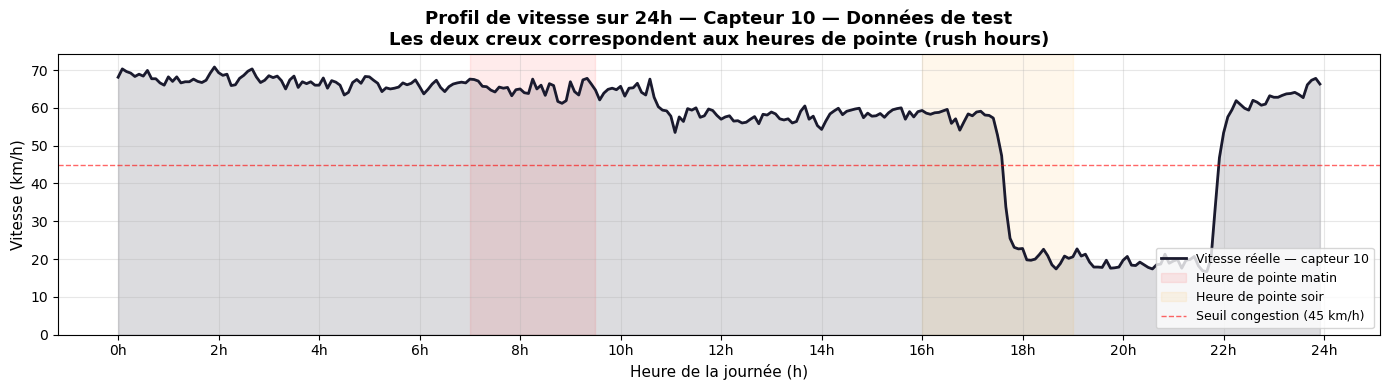


Fenêtres train : 34,743
Fenêtres test  : 8,686

Naïf     | MAE=4.479  RMSE=9.173  MAPE=10.2%  R²=0.020
HA       | MAE=2.270  RMSE=4.009  MAPE=5.0%  R²=0.813

Ajustement ARIMA(2,1,2) sur capteur 10 ...
ARIMA glissant (rolling) — patience ...


C:\Users\ilyas\anaconda3\envs\trafficAI\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ilyas\anaconda3\envs\trafficAI\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ilyas\anaconda3\envs\trafficAI\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ilyas\anaconda3\envs\trafficAI\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ilyas\anaconda3\envs\trafficAI\

ARIMA multi  | MAE = 4.883 km/h
ARIMA rolling| MAE = 1.320 km/h


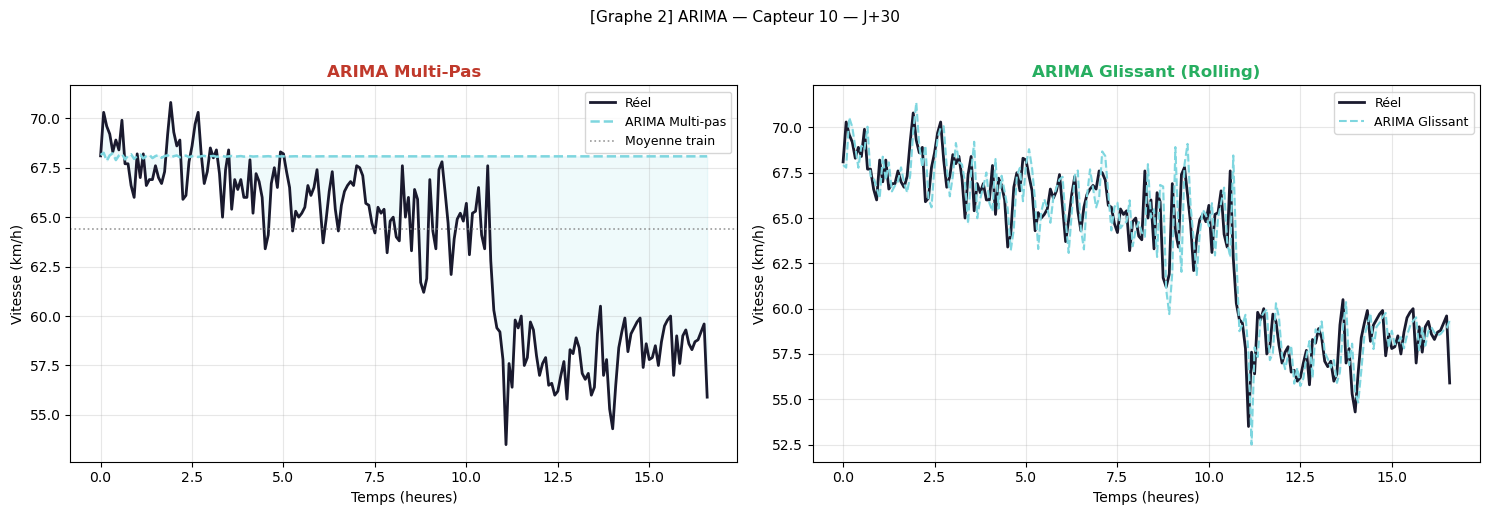


Filtre de Kalman — capteur 10 ...
Kalman   | MAE=11.602  RMSE=17.880 km/h (capteur 10)

SVR — capteur 10 | fenêtre=24 | train=5000 ...
SVR      | MAE=6.545  RMSE=13.726 km/h (capteur 10)

CNN params : 43,154

───────────────────────────────────────────────────────
  Entraînement : CNN (dilaté)  (30 epochs)
───────────────────────────────────────────────────────
     1      0.934116    1.015473    3.00e-04
     2      0.856210    1.019617    3.00e-04
     3      0.812457    1.021812    3.00e-04
     4      0.781702    1.025142    3.00e-04
     5      0.754978    1.040109    3.00e-04
     6      0.733847    1.035632    1.50e-04 ← LR↓
     7      0.712950    1.033265    1.50e-04
     8      0.704839    1.032043    1.50e-04
     9      0.696199    1.030857    1.50e-04
    10      0.687551    1.039000    1.50e-04
    11      0.680143    1.038260    7.50e-05 ← LR↓
    12      0.671263    1.035519    7.50e-05
    13      0.667543    1.037509    7.50e-05
    14      0.665416    1.037678    7.

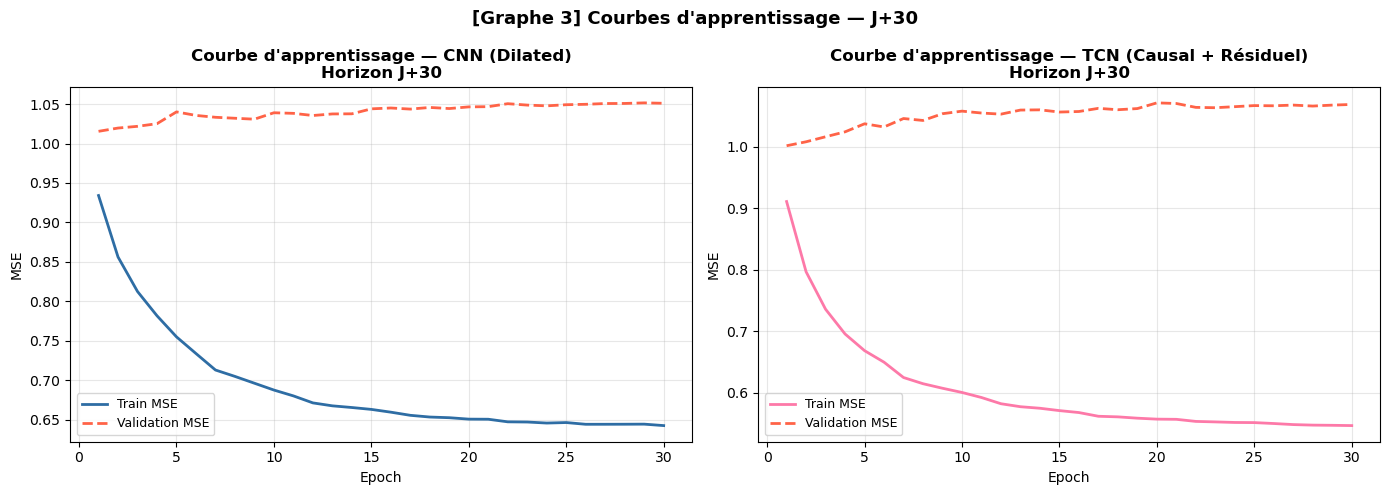

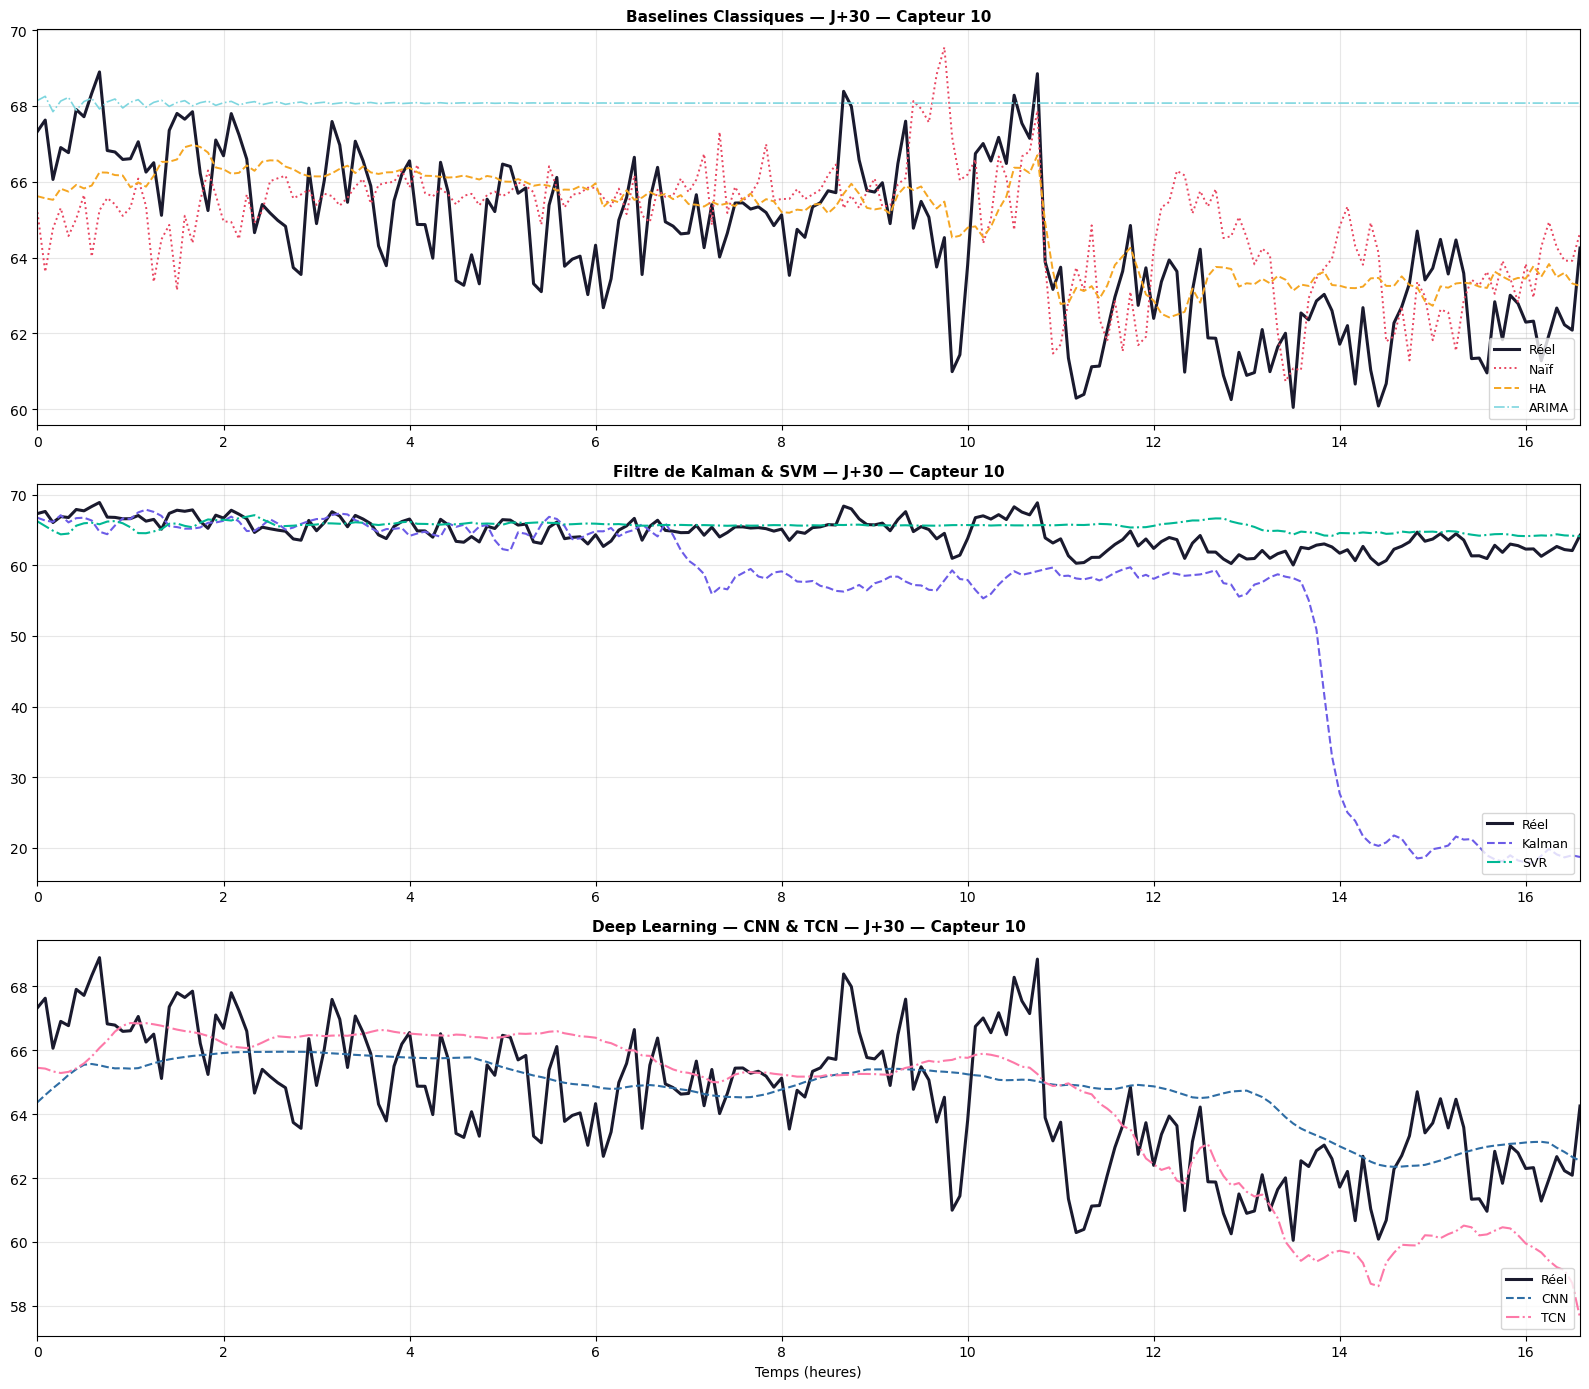


══════════════════════════════════════════════════════════════════════
  RÉSULTATS COMPLETS — J+30 — PeMS-Bay
══════════════════════════════════════════════════════════════════════
        Modèle MAE (km/h) RMSE (km/h)
          Naïf      4.479       9.173
            HA      2.270       4.009
 CNN (dilated)      3.642       7.273
  TCN (causal)      3.488       7.213
  ARIMA multi*      4.883           —
ARIMA rolling*      1.320           —
       Kalman*     11.602      17.880
          SVR*      6.545      13.726


In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  NOTEBOOK CNN — PARTIE 1 : J+30 (1 MOIS)                       ║
# ║  Modèles : Naïf | HA | ARIMA | Kalman | SVM | CNN | TCN        ║
# ║  Dataset  : PeMS-Bay | 325 capteurs | 5 min | 6 mois           ║
# ╚══════════════════════════════════════════════════════════════════╝

import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import IncrementalPCA
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler as SKScaler
from statsmodels.tsa.arima.model import ARIMA

# ── Chemins ────────────────────────────────────────────────────────
H5_PATH = r"C:\Users\ilyas\Desktop\traffic_project\data\pems-bay.h5"

# ── Paramètres de l'horizon J+30 (1 Mois) ──────────────────────────
HORIZON_LABEL = "J+30"
WINDOW        = 48       # 4h d'historique en entrée (48 × 5min)
HORIZON       = 8640     # cible : 30 jours plus tard (30 × 288 = 8640 pas)

# ── Hyperparamètres communs ────────────────────────────────────────
TRAIN_RATIO   = 0.80
N_COMPONENTS  = 50       # PCA : 325 capteurs → 50 composantes
EPOCHS        = 30
BATCH_SIZE    = 32
LR            = 3e-4

# ── Capteur utilisé pour les graphes 1-capteur ─────────────────────
SENSOR        = 10       # capteur de référence pour les graphes
PLOT_STEPS    = 288      # nombre de pas affichés sur les graphes (1 jour)

# ── Reproductibilité ───────────────────────────────────────────────
np.random.seed(42)
torch.manual_seed(42)

# ── Palette de couleurs (cohérente sur tous les graphes) ───────────
COLORS = {
    "real":   "#1a1a2e",   # noir bleu foncé
    "naive":  "#e94560",   # rouge
    "ha":     "#f5a623",   # orange
    "arima":  "#7ed6df",   # cyan
    "kalman": "#6c5ce7",   # violet
    "svm":    "#00b894",   # vert
    "cnn":    "#2e6da4",   # bleu
    "tcn":    "#fd79a8",   # rose
}

print("=" * 65)
print(f"  CNN NOTEBOOK — Horizon {HORIZON_LABEL}")
print(f"  Window  : {WINDOW} pas = {WINDOW*5//60}h d'historique")
print(f"  Horizon : {HORIZON} pas = {HORIZON//288} jour(s) dans le futur")
print(f"  PyTorch : {torch.__version__}")
print("=" * 65)

# ══════════════════════════════════════════════════════════════════
# CELL 1 — CHARGEMENT & PRÉTRAITEMENT
# ══════════════════════════════════════════════════════════════════
df = pd.read_hdf(H5_PATH)

# Correction bug pandas timezone (index timezone-aware → naïf)
df.index = pd.to_datetime(df.index, utc=True).tz_localize(None)
df = df.sort_index().astype(np.float32)
df = df.ffill().bfill()   # remplissage valeurs manquantes

T, S = df.shape
print(f"\nDataset : {T} pas × {S} capteurs")
print(f"Période : {df.index[0]}  →  {df.index[-1]}")
print(f"Vitesse : {df.values.min():.1f} – {df.values.max():.1f} km/h")

assert T >= WINDOW + HORIZON + 500, "Pas assez de données pour un horizon d'un mois"

split_t = int(T * TRAIN_RATIO)
print(f"Split   : {split_t} train | {T - split_t} test (80/20 chronologique)")

# ── Normalisation — fit sur train UNIQUEMENT (anti-leakage) ────────
train_raw = df.values[:split_t]
mu  = train_raw.mean(axis=0)          # moyenne par capteur
sig = train_raw.std(axis=0)           # écart-type par capteur
sig = np.where(sig == 0, 1.0, sig)   # éviter division par zéro

values_raw = df.values.copy()         # gardé pour ARIMA et Kalman (km/h réels)
del df; gc.collect()

values_sc = ((values_raw - mu) / sig).astype(np.float32)
print(f"Tableau normalisé : {values_sc.nbytes/1e6:.0f} MB ✓")

# ── Tableau des temps pour la Moyenne Historique ───────────────────
t_start = pd.Timestamp("2017-01-01")
time_index = pd.date_range(t_start, periods=T, freq="5min")

# ══════════════════════════════════════════════════════════════════
# CELL 2 — PCA : 325 CAPTEURS → 50 COMPOSANTES
# ══════════════════════════════════════════════════════════════════
print(f"\nAjustement IncrementalPCA({N_COMPONENTS}) sur l'ensemble train ...")
pca = IncrementalPCA(n_components=N_COMPONENTS, batch_size=2000)
pca.fit(values_sc[:split_t])

explained = pca.explained_variance_ratio_.sum() * 100
print(f"Variance expliquée : {explained:.1f}% avec {N_COMPONENTS} composantes")

values_pca = pca.transform(values_sc).astype(np.float32)
print(f"Tableau PCA : {values_pca.nbytes/1e6:.0f} MB (vs {values_sc.nbytes/1e6:.0f} MB avant)")

pca_train = values_pca[:split_t]
pca_mu  = pca_train.mean(axis=0)
pca_sig = pca_train.std(axis=0)
pca_sig = np.where(pca_sig == 0, 1.0, pca_sig)
del values_sc, pca_train; gc.collect()
print("PCA terminé ✓")

# ══════════════════════════════════════════════════════════════════
# CELL 3 — [GRAPHE 1] PROFIL DE VITESSE (SANITY CHECK)
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 4))
day_vals = values_raw[split_t : split_t + 288, SENSOR]   # 1 jour du test
steps    = np.arange(288)
hours    = steps * 5 / 60

ax.fill_between(hours, day_vals, alpha=0.15, color=COLORS["real"])
ax.plot(hours, day_vals, color=COLORS["real"], lw=2.0, label=f"Vitesse réelle — capteur {SENSOR}")

# Zones heures de pointe (approximatives)
ax.axvspan(7, 9.5,  alpha=0.08, color="red",   label="Heure de pointe matin")
ax.axvspan(16, 19,  alpha=0.08, color="orange", label="Heure de pointe soir")
ax.axhline(y=45, color="red", ls="--", lw=1.0, alpha=0.6, label="Seuil congestion (45 km/h)")

ax.set_title(
    f"Profil de vitesse sur 24h — Capteur {SENSOR} — Données de test\n"
    "Les deux creux correspondent aux heures de pointe (rush hours)",
    fontsize=13, fontweight="bold")
ax.set_xlabel("Heure de la journée (h)", fontsize=11)
ax.set_ylabel("Vitesse (km/h)", fontsize=11)
ax.set_xticks(range(0, 25, 2))
ax.set_xticklabels([f"{h}h" for h in range(0, 25, 2)])
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
ax.set_ylim(0, None)

plt.tight_layout()
plt.savefig(f"g1_profil_24h_{HORIZON_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

del day_vals; gc.collect()

# ══════════════════════════════════════════════════════════════════
# CELL 4 — DATASET PyTorch ON-THE-FLY
# ══════════════════════════════════════════════════════════════════
class TrafficDataset(Dataset):
    def __init__(self, v, mu, sig, start, end, window, horizon):
        self.v, self.mu, self.sig = v, mu, sig
        self.start, self.end      = start, end
        self.window, self.horizon = window, horizon

    def __len__(self):
        return self.end - self.start

    def __getitem__(self, idx):
        i  = self.start + idx
        x  = (self.v[i : i + self.window] - self.mu) / self.sig
        y  = (self.v[i + self.window + self.horizon - 1] - self.mu) / self.sig
        return torch.from_numpy(x), torch.from_numpy(y)

N_total = T - WINDOW - HORIZON + 1
split_w = int(N_total * TRAIN_RATIO)

train_ds = TrafficDataset(values_pca, pca_mu, pca_sig, 0,       split_w,  WINDOW, HORIZON)
test_ds  = TrafficDataset(values_pca, pca_mu, pca_sig, split_w, N_total,  WINDOW, HORIZON)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(test_ds,  batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0)

print(f"\nFenêtres train : {len(train_ds):,}")
print(f"Fenêtres test  : {len(test_ds):,}")

# ══════════════════════════════════════════════════════════════════
# CELL 5 — MODÈLE NAÏF + MOYENNE HISTORIQUE (HA)
# ══════════════════════════════════════════════════════════════════
def pca_to_kmh(x_sc):
    return pca.inverse_transform(x_sc * pca_sig + pca_mu) * sig + mu

def mae_rmse_mape_r2(y_true, y_pred):
    err  = y_pred - y_true
    mae  = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    mask = y_true > 1
    mape = float(np.mean(np.abs(err[mask] / y_true[mask])) * 100)
    ss_res = np.sum(err**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    r2   = float(1 - ss_res / ss_tot)
    return mae, rmse, mape, r2

naive_preds, targets = [], []
for xb, yb in val_loader:
    naive_preds.append(xb[:, -1, :].numpy())
    targets.append(yb.numpy())

y_naive_sc = np.concatenate(naive_preds)
y_test_sc  = np.concatenate(targets)
del naive_preds, targets; gc.collect()

y_test_kmh  = pca_to_kmh(y_test_sc)
y_naive_kmh = pca_to_kmh(y_naive_sc)

mae_n, rmse_n, mape_n, r2_n = mae_rmse_mape_r2(y_test_kmh, y_naive_kmh)
print(f"\nNaïf     | MAE={mae_n:.3f}  RMSE={rmse_n:.3f}  MAPE={mape_n:.1f}%  R²={r2_n:.3f}")

# Moyenne Historique (HA)
ha_lookup = {}
for i in range(split_t - HORIZON):
    target_idx = i + WINDOW + HORIZON - 1
    if target_idx >= split_t:
        break
    t_target = time_index[target_idx]
    key = (t_target.dayofweek, t_target.hour * 12 + t_target.minute // 5)
    if key not in ha_lookup:
        ha_lookup[key] = []
    ha_lookup[key].append(values_raw[target_idx])

ha_mean = {k: np.mean(v, axis=0) for k, v in ha_lookup.items()}

ha_preds = []
for j in range(len(test_ds)):
    target_idx = split_w + j + WINDOW + HORIZON - 1
    t_target   = time_index[min(target_idx, T-1)]
    key = (t_target.dayofweek, t_target.hour * 12 + t_target.minute // 5)
    ha_preds.append(ha_mean.get(key, mu))

y_ha_kmh = np.array(ha_preds, dtype=np.float32)
mae_ha, rmse_ha, mape_ha, r2_ha = mae_rmse_mape_r2(y_test_kmh, y_ha_kmh)
print(f"HA       | MAE={mae_ha:.3f}  RMSE={rmse_ha:.3f}  MAPE={mape_ha:.1f}%  R²={r2_ha:.3f}")

# ══════════════════════════════════════════════════════════════════
# CELL 6 — [GRAPHE 2] ARIMA SEUL — MULTI-PAS vs GLISSANT
# ══════════════════════════════════════════════════════════════════
s = values_raw[:, SENSOR]
train_s = s[:split_t].astype(float)
test_s  = s[split_t:].astype(float)
N_SHOW  = min(200, len(test_ds))

print(f"\nAjustement ARIMA(2,1,2) sur capteur {SENSOR} ...")
arima_model = ARIMA(train_s, order=(2, 1, 2)).fit()

arima_multi = arima_model.forecast(steps=N_SHOW)

print("ARIMA glissant (rolling) — patience ...")
arima_roll = []
history = list(train_s[-200:])
for k in range(N_SHOW):
    m_tmp = ARIMA(history[-200:], order=(2, 1, 2)).fit()
    arima_roll.append(m_tmp.forecast(steps=1)[0])
    history.append(test_s[k])
arima_roll = np.array(arima_roll)

mae_arima_multi = float(np.mean(np.abs(arima_multi[:N_SHOW] - test_s[:N_SHOW])))
mae_arima_roll  = float(np.mean(np.abs(arima_roll            - test_s[:N_SHOW])))

print(f"ARIMA multi  | MAE = {mae_arima_multi:.3f} km/h")
print(f"ARIMA rolling| MAE = {mae_arima_roll:.3f} km/h")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
steps_show = np.arange(N_SHOW) * 5 / 60

ax = axes[0]
ax.plot(steps_show, test_s[:N_SHOW], color=COLORS["real"],  lw=2.0, label="Réel")
ax.plot(steps_show, arima_multi[:N_SHOW], color=COLORS["arima"], lw=1.8, ls="--", label=f"ARIMA Multi-pas")
ax.axhline(y=train_s.mean(), color="grey", ls=":", lw=1.2, alpha=0.8, label="Moyenne train")
ax.fill_between(steps_show, arima_multi[:N_SHOW], test_s[:N_SHOW], alpha=0.12, color=COLORS["arima"])
ax.set_title("ARIMA Multi-Pas", fontsize=12, fontweight="bold", color="#c0392b")
ax.set_xlabel("Temps (heures)"); ax.set_ylabel("Vitesse (km/h)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(steps_show, test_s[:N_SHOW], color=COLORS["real"],  lw=2.0, label="Réel")
ax.plot(steps_show, arima_roll, color=COLORS["arima"], lw=1.5, ls="--", label=f"ARIMA Glissant")
ax.fill_between(steps_show, arima_roll, test_s[:N_SHOW], alpha=0.12, color=COLORS["arima"])
ax.set_title("ARIMA Glissant (Rolling)", fontsize=12, fontweight="bold", color="#27ae60")
ax.set_xlabel("Temps (heures)"); ax.set_ylabel("Vitesse (km/h)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

fig.suptitle(f"[Graphe 2] ARIMA — Capteur {SENSOR} — {HORIZON_LABEL}", fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f"g2_arima_comparison_{HORIZON_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════
# CELL 7 — FILTRE DE KALMAN (1 capteur)
# ══════════════════════════════════════════════════════════════════
def kalman_filter_predict(series_train, series_test, horizon):
    diffs = np.diff(series_train)
    Q = float(np.var(diffs))
    R = float(np.var(series_train) * 0.1)
    
    x = series_train[-1]
    P, F, H = 1.0, 1.0, 1.0
    preds = []
    
    for k in range(len(series_test)):
        x_pred = F * x
        P_pred = F * P * F + Q
        K = P_pred * H / (H * P_pred * H + R)
        
        if k < horizon:
            x = x_pred
        else:
            z = series_test[k - horizon]
            x = x_pred + K * (z - H * x_pred)
        
        P = (1 - K * H) * P_pred
        preds.append(x_pred)
        
    return np.array(preds)

print(f"\nFiltre de Kalman — capteur {SENSOR} ...")
kalman_preds_1s = kalman_filter_predict(train_s, test_s, horizon=HORIZON)

align_start = WINDOW + HORIZON - 1
n_test_w    = len(test_ds)
kalman_1s   = kalman_preds_1s[align_start : align_start + n_test_w]
real_1s     = test_s[align_start : align_start + n_test_w]

mae_kalman  = float(np.mean(np.abs(kalman_1s - real_1s)))
rmse_kalman = float(np.sqrt(np.mean((kalman_1s - real_1s)**2)))
print(f"Kalman   | MAE={mae_kalman:.3f}  RMSE={rmse_kalman:.3f} km/h (capteur {SENSOR})")

# ══════════════════════════════════════════════════════════════════
# CELL 8 — SVM (SVR — Support Vector Regression)
# ══════════════════════════════════════════════════════════════════
SVR_WINDOW  = 24
N_TRAIN_SVR = 5000
N_TEST_SVR  = min(n_test_w, 3000)

print(f"\nSVR — capteur {SENSOR} | fenêtre={SVR_WINDOW} | train={N_TRAIN_SVR} ...")

def build_windows_1d(series, window, horizon, n_max=None):
    X, y = [], []
    limit = len(series) - window - horizon + 1
    if n_max: limit = min(limit, n_max + window + horizon)
    for i in range(limit):
        X.append(series[i : i + window])
        y.append(series[i + window + horizon - 1])
    return np.array(X), np.array(y)

full_s = values_raw[:, SENSOR]
X_all, y_all = build_windows_1d(full_s, SVR_WINDOW, HORIZON)

X_train_svr = X_all[:N_TRAIN_SVR]
y_train_svr = y_all[:N_TRAIN_SVR]
X_test_svr  = X_all[split_w : split_w + N_TEST_SVR]
y_test_svr  = y_all[split_w : split_w + N_TEST_SVR]

scaler_svr = SKScaler()
X_train_sc = scaler_svr.fit_transform(X_train_svr)
X_test_sc  = scaler_svr.transform(X_test_svr)

svr_model = SVR(kernel="rbf", C=10, epsilon=0.5, gamma="scale")
svr_model.fit(X_train_sc, y_train_svr)
y_svr_pred = svr_model.predict(X_test_sc)

mae_svr  = float(np.mean(np.abs(y_svr_pred - y_test_svr)))
rmse_svr = float(np.sqrt(np.mean((y_svr_pred - y_test_svr)**2)))
print(f"SVR      | MAE={mae_svr:.3f}  RMSE={rmse_svr:.3f} km/h (capteur {SENSOR})")

# ══════════════════════════════════════════════════════════════════
# CELL 9 — CNN (Dilated Temporal Convolutions + PCA)
# ══════════════════════════════════════════════════════════════════
class CNNForecaster(nn.Module):
    def __init__(self, n_comp, window):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(n_comp, 32, kernel_size=3, padding=1,  dilation=1), nn.ReLU(),
            nn.Conv1d(32,     64, kernel_size=3, padding=2,  dilation=2), nn.ReLU(),
            nn.Conv1d(64,     64, kernel_size=3, padding=4,  dilation=4), nn.ReLU(),
            nn.Conv1d(64,     64, kernel_size=3, padding=8,  dilation=8), nn.ReLU(),
        )
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(64, 64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, n_comp)
        )

    def forward(self, x):
        return self.head(self.gap(self.encoder(x.permute(0,2,1))).squeeze(-1))

device    = torch.device("cpu")
cnn_model = CNNForecaster(N_COMPONENTS, WINDOW).to(device)
print(f"\nCNN params : {sum(p.numel() for p in cnn_model.parameters()):,}")

def train_model(model, name, epochs=EPOCHS):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=4)
    loss_fn   = nn.MSELoss()
    tr_losses, val_losses = [], []
    prev_lr = LR
    print(f"\n{'─'*55}")
    print(f"  Entraînement : {name}  ({epochs} epochs)")
    print(f"{'─'*55}")
    
    for ep in range(1, epochs + 1):
        model.train(); tot, n = 0.0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tot += loss.item() * len(xb); n += len(xb)
        
        model.eval(); vtot, vn = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                pred = model(xb)
                vtot += loss_fn(pred, yb).item() * len(xb); vn += len(xb)
        
        tr = tot / n; vl = vtot / vn
        scheduler.step(vl)
        tr_losses.append(tr); val_losses.append(vl)
        
        cur_lr = optimizer.param_groups[0]["lr"]
        tag    = " ← LR↓" if cur_lr < prev_lr else ""
        prev_lr = cur_lr
        print(f"{ep:>6}  {tr:>12.6f}  {vl:>10.6f}  {cur_lr:>10.2e}{tag}")
    return tr_losses, val_losses

cnn_tr_losses, cnn_val_losses = train_model(cnn_model, "CNN (dilaté)")

def get_predictions(model):
    model.eval(); preds = []
    with torch.no_grad():
        for xb, _ in val_loader:
            preds.append(model(xb).numpy())
    return pca_to_kmh(np.concatenate(preds))

y_cnn_kmh = get_predictions(cnn_model)
mae_cnn, rmse_cnn, mape_cnn, r2_cnn = mae_rmse_mape_r2(y_test_kmh, y_cnn_kmh)
print(f"\nCNN      | MAE={mae_cnn:.3f}  RMSE={rmse_cnn:.3f}  MAPE={mape_cnn:.1f}%  R²={r2_cnn:.3f}")

# ══════════════════════════════════════════════════════════════════
# CELL 10 — TCN — Temporal Convolutional Network
# ══════════════════════════════════════════════════════════════════
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation)
        self.cut  = pad
    def forward(self, x):
        out = self.conv(x)
        return out[:, :, : -self.cut] if self.cut > 0 else out

class TCNBlock(nn.Module):
    def __init__(self, n_ch, kernel_size, dilation):
        super().__init__()
        self.causal1 = CausalConv1d(n_ch, n_ch, kernel_size, dilation)
        self.causal2 = CausalConv1d(n_ch, n_ch, kernel_size, dilation)
        self.norm1   = nn.LayerNorm(n_ch)
        self.norm2   = nn.LayerNorm(n_ch)
        self.drop    = nn.Dropout(0.1)
        self.relu    = nn.ReLU()
    def forward(self, x):
        residual = x
        out = self.relu(self.norm1(self.causal1(x).permute(0,2,1)).permute(0,2,1))
        out = self.drop(out)
        out = self.relu(self.norm2(self.causal2(out).permute(0,2,1)).permute(0,2,1))
        return self.relu(out + residual)

class TCNForecaster(nn.Module):
    def __init__(self, n_comp, window, kernel_size=3):
        super().__init__()
        self.input_proj = nn.Conv1d(n_comp, 64, kernel_size=1)
        self.blocks = nn.Sequential(
            TCNBlock(64, kernel_size, dilation=1),
            TCNBlock(64, kernel_size, dilation=2),
            TCNBlock(64, kernel_size, dilation=4),
            TCNBlock(64, kernel_size, dilation=8),
        )
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(64, 64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, n_comp)
        )
    def forward(self, x):
        x = self.input_proj(x.permute(0, 2, 1))
        x = self.blocks(x)
        x = self.gap(x).squeeze(-1)
        return self.head(x)

tcn_model = TCNForecaster(N_COMPONENTS, WINDOW).to(device)
tcn_tr_losses, tcn_val_losses = train_model(tcn_model, "TCN (causal + résiduel)")
y_tcn_kmh = get_predictions(tcn_model)

mae_tcn, rmse_tcn, mape_tcn, r2_tcn = mae_rmse_mape_r2(y_test_kmh, y_tcn_kmh)
print(f"\nTCN      | MAE={mae_tcn:.3f}  RMSE={rmse_tcn:.3f}  MAPE={mape_tcn:.1f}%  R²={r2_tcn:.3f}")

# ══════════════════════════════════════════════════════════════════
# CELL 11 — [GRAPHE 3] COURBES D'APPRENTISSAGE
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_x = range(1, EPOCHS + 1)
for ax, (tr, vl, name, color) in zip(axes, [
    (cnn_tr_losses, cnn_val_losses, "CNN (Dilated)", COLORS["cnn"]),
    (tcn_tr_losses, tcn_val_losses, "TCN (Causal + Résiduel)", COLORS["tcn"]),
]):
    ax.plot(epochs_x, tr, color=color,   lw=2.0, label="Train MSE")
    ax.plot(epochs_x, vl, color="tomato", lw=2.0, ls="--", label="Validation MSE")
    ax.set_title(f"Courbe d'apprentissage — {name}\nHorizon {HORIZON_LABEL}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

fig.suptitle(f"[Graphe 3] Courbes d'apprentissage — {HORIZON_LABEL}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"g3_training_curves_{HORIZON_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════
# CELL 12 — [GRAPHE 4] COMPARAISON COMPLÈTE
# ══════════════════════════════════════════════════════════════════
n = min(PLOT_STEPS, n_test_w, len(kalman_1s), N_TEST_SVR, N_SHOW)
t_hours = np.arange(n) * 5 / 60

real_plot   = y_test_kmh[:n, SENSOR]
naive_plot  = y_naive_kmh[:n, SENSOR]
ha_plot     = y_ha_kmh[:n, SENSOR] if y_ha_kmh.ndim > 1 else y_ha_kmh[:n]
cnn_plot    = y_cnn_kmh[:n, SENSOR]
tcn_plot    = y_tcn_kmh[:n, SENSOR]
kalman_plot = kalman_1s[:n]
svr_plot    = y_svr_pred[:n]
arima_plot  = arima_multi[:n]

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Baselines
ax = axes[0]
ax.plot(t_hours, real_plot,  color=COLORS["real"],  lw=2.2, label="Réel")
ax.plot(t_hours, naive_plot, color=COLORS["naive"], lw=1.4, ls=":", label=f"Naïf")
ax.plot(t_hours, ha_plot,    color=COLORS["ha"],    lw=1.4, ls="--", label=f"HA")
ax.plot(t_hours, arima_plot, color=COLORS["arima"], lw=1.2, ls="-.", label=f"ARIMA")
ax.set_title(f"Baselines Classiques — {HORIZON_LABEL} — Capteur {SENSOR}", fontsize=11, fontweight="bold")
ax.legend(fontsize=9, loc="lower right"); ax.grid(alpha=0.3); ax.set_xlim(0, t_hours[-1])

# Signal Models
ax = axes[1]
ax.plot(t_hours, real_plot,   color=COLORS["real"],   lw=2.2, label="Réel")
ax.plot(t_hours, kalman_plot, color=COLORS["kalman"], lw=1.5, ls="--", label=f"Kalman")
ax.plot(t_hours, svr_plot,    color=COLORS["svm"],    lw=1.5, ls="-.", label=f"SVR")
ax.set_title(f"Filtre de Kalman & SVM — {HORIZON_LABEL} — Capteur {SENSOR}", fontsize=11, fontweight="bold")
ax.legend(fontsize=9, loc="lower right"); ax.grid(alpha=0.3); ax.set_xlim(0, t_hours[-1])

# Deep Learning
ax = axes[2]
ax.plot(t_hours, real_plot, color=COLORS["real"], lw=2.2, label="Réel")
ax.plot(t_hours, cnn_plot,  color=COLORS["cnn"],  lw=1.5, ls="--", label=f"CNN")
ax.plot(t_hours, tcn_plot,  color=COLORS["tcn"],  lw=1.5, ls="-.", label=f"TCN")
ax.set_title(f"Deep Learning — CNN & TCN — {HORIZON_LABEL} — Capteur {SENSOR}", fontsize=11, fontweight="bold")
ax.set_xlabel("Temps (heures)"); ax.legend(fontsize=9, loc="lower right"); ax.grid(alpha=0.3); ax.set_xlim(0, t_hours[-1])

plt.tight_layout()
plt.savefig(f"g4_full_comparison_{HORIZON_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════
# CELL 13, 14, 15, 16 — METRICS & SAUVEGARDE
# ══════════════════════════════════════════════════════════════════
results_data = {
    "Modèle":      ["Naïf", "HA", "CNN (dilated)", "TCN (causal)", "ARIMA multi*", "ARIMA rolling*", "Kalman*", "SVR*"],
    "MAE (km/h)":  [f"{mae_n:.3f}", f"{mae_ha:.3f}", f"{mae_cnn:.3f}", f"{mae_tcn:.3f}",
                    f"{mae_arima_multi:.3f}", f"{mae_arima_roll:.3f}", f"{mae_kalman:.3f}", f"{mae_svr:.3f}"],
    "RMSE (km/h)": [f"{rmse_n:.3f}", f"{rmse_ha:.3f}", f"{rmse_cnn:.3f}", f"{rmse_tcn:.3f}",
                    "—", "—", f"{rmse_kalman:.3f}", f"{rmse_svr:.3f}"],
}

df_res = pd.DataFrame(results_data)
print("\n" + "═"*70)
print(f"  RÉSULTATS COMPLETS — {HORIZON_LABEL} — PeMS-Bay")
print("═"*70)
print(df_res.to_string(index=False))
df_res.to_csv(f"results_{HORIZON_LABEL}.csv", index=False)